# Predicting Student Academic Performance Using Machine Learning and Explainable AI

**Author:** Prabin Pokhrel  
**Registration Number:** 2308806  
**Course:** CPS6001  
**Supervisor:** Elisabetta Canetta  
**Dataset:** UCI Student Performance Dataset (`student-mat.csv` and `student-por.csv`)

---

## Abstract

This project builds a machine learning pipeline that predicts whether a student will pass or fail based on demographic, family, and behavioural data from the UCI Student Performance Dataset. Most existing work in this area focuses only on prediction accuracy, treating the model as a black box and ignoring whether the predictions are fair across student groups. This project addresses both gaps.

Three classification models are trained and compared: Logistic Regression as a simple interpretable baseline, Random Forest, and XGBoost. Global explainability is provided through SHAP — which shows which features influence predictions across the entire dataset — and local explainability through LIME, which explains individual student predictions case by case. A fairness analysis then checks whether the model performs consistently across gender, residential area, parental education level, and subject.

Three structured experiments compare baseline models, models with seven engineered features added, and tuned models after hyperparameter optimisation. McNemar's test checks whether model differences are statistically significant. Both UCI subject datasets (Mathematics and Portuguese Language) are merged and tagged with a subject identifier, giving 1,044 records total and enabling a cross-subject generalisation test.

---

## Notebook Structure

| Section | Title |
|---------|-------|
| 1 | Environment Setup |
| 2 | Dataset Loading and Integration |
| 3 | Target Variable Construction and Leakage Removal |
| 4 | Data Quality Validation |
| 5 | Exploratory Data Analysis |
| 6 | Feature Engineering |
| 7 | Preprocessing Pipeline |
| 8 | Experimental Design |
| 9 | Model Training and Hyperparameter Tuning |
| 10 | Model Evaluation and Comparison |
| 11 | Explainability — SHAP (Global) |
| 12 | Explainability — LIME (Local) |
| 13 | SHAP and LIME Comparative Analysis |
| 14 | Fairness and Bias Analysis |
| 15 | Cross-Subject Generalisation |
| 16 | Results Summary and Conclusions |

---

## Introduction

Predicting whether a student is likely to fail is genuinely useful — schools can use early warnings to direct tutoring, pastoral support, or parental contact before the situation becomes irreversible. The problem is that most machine learning models used for this purpose are black boxes. A teacher cannot act on a prediction they cannot understand, and a model that works well on average but poorly for certain student groups is not fit for responsible use.

I chose this project because that gap is real and practical. I wanted to build something that predicts outcome accurately, explains its reasoning in a way educators can engage with, and can be audited to check it is not systematically disadvantaging particular groups of students. The UCI Student Performance Dataset (Cortez and Silva, 2008) is well-established, publicly available, and contains exactly the range of demographic and behavioural features that matter for this kind of analysis.

---

## Research Question

**How can Explainable AI techniques — specifically SHAP and LIME — be used to improve the interpretability and fairness of machine learning models that predict student academic performance from demographic, behavioural, and academic data?**

---

## Objectives

| # | Objective | Addressed In |
|---|-----------|-------------|
| 1 | Systematic review of related literature on student performance prediction | Introduction, Prior Work, References |
| 2 | Collect, clean, and preprocess the UCI Student Performance dataset | Sections 2–7 |
| 3 | Train Logistic Regression, Random Forest, and XGBoost models | Sections 8–9 |
| 4 | Apply SHAP (global) and LIME (local) for model interpretability | Sections 11–13 |
| 5 | Evaluate model performance using F1, ROC-AUC, precision, recall, accuracy | Section 10 |
| 6 | Assess fairness across demographic subgroups | Section 14 |
| 7 | Summarise findings and produce output visualisations | Section 16 |

---

## Prior Work

Research into predicting student academic performance with machine learning goes back at least to Cortez and Silva (2008), who applied decision trees and neural networks to Portuguese secondary school data and found that study time, past failures, and parental education were the strongest predictors. Their dataset — the one used in this project — became the benchmark for subsequent work in this area, and their findings on key predictors are used here as a baseline against which SHAP results are compared.

Systematic reviews by Albreiki et al. (2021) and De-La-Cruz et al. (2022) confirm that accuracy has improved as more powerful models have been applied, but both highlight the same persistent problem: most studies report accuracy and stop there. The models are treated as black boxes. Khosravi et al. (2022) make this explicit in the context of AI in education, arguing that interpretability is not optional if predictions are going to be used in real settings where educators need to justify and act on model outputs.

The fairness dimension is even less covered. Mehrabi et al. (2019) survey bias in machine learning broadly, and Kesgin et al. (2025) is one of the very few papers to address both explainability and fairness in student performance prediction directly. They show that models can exhibit measurable performance disparities across gender and socioeconomic groups even when overall accuracy looks acceptable. The fairness evaluation in Section 14 follows that approach, using subgroup accuracy, equal opportunity, and demographic parity differences across four sensitive attributes.

For the explainability methods: SHAP is grounded in cooperative game theory (Lundberg and Lee, 2017) and provides theoretically consistent feature attributions with formal guarantees of local accuracy, missingness, and consistency. LIME (Ribeiro et al., 2016) takes a different approach by fitting a weighted linear model in a small neighbourhood around each prediction. Using both methods together is deliberate: where they agree, confidence in the explanation is higher; where they disagree, that signals instability in the model's decision boundary at that point.

---

## Ethical Considerations

This project uses the UCI Student Performance Dataset — a publicly available, fully anonymised dataset collected from Portuguese secondary schools (UCI Machine Learning Repository, 2008). No personal or identifiable information is processed. Formal ethics approval is not required under the university guidelines for secondary, anonymised, open-access datasets.

All data is used only for academic research, stored only within this project directory, and handled in line with data protection principles. The models built here are intended as decision-support tools to help educators identify students who may need support. They should not replace professional judgement or be used to make consequential decisions about real students outside this research context.

---

## Section 1: Environment Setup

### Rationale

Reproducibility is a foundational requirement of academic research. This section ensures that all dependencies are available and that all stochastic processes — including train-test splitting, model initialisation, and cross-validation fold assignment — are governed by a fixed random seed. The constant `RANDOM_STATE = 42` is applied consistently throughout the notebook. Any researcher running this notebook with the same data and the same seed should obtain identical numerical results.

Output directories for figures and tables are created at this stage so that all downstream cells can write to them without error.

In [1]:
# ------------------------------------------------------------
# Cell 1.1: Dependency installation
# Checks for each required package and installs only those
# that are absent. Safe to re-run; already-installed packages
# are skipped without modification.
# ------------------------------------------------------------
import subprocess
import sys

REQUIRED_PACKAGES = [
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'xgboost',
    'shap',
    'lime',
]

for package in REQUIRED_PACKAGES:
    import_name = package.replace('-', '_')
    try:
        __import__(import_name)
        print(f'  [OK]  {package}')
    except ImportError:
        print(f'  [INSTALLING]  {package} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '-q'])
        print(f'  [INSTALLED]   {package}')

print('\nAll required packages are available.')

  [OK]  pandas
  [OK]  numpy
  [OK]  matplotlib


  [OK]  seaborn
  [INSTALLING]  scikit-learn ...


  [INSTALLED]   scikit-learn


  [OK]  xgboost


  [OK]  shap
  [OK]  lime

All required packages are available.


C:\Users\prabi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ------------------------------------------------------------
# Cell 1.2: Library imports
# All imports are declared here to make the dependency surface
# visible and to avoid repeated imports across cells.
# ------------------------------------------------------------
import os
import warnings
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing
from sklearn.model_selection  import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline         import Pipeline
from sklearn.impute           import SimpleImputer

# Scikit-learn: models
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier

# Scikit-learn: metrics
from sklearn.metrics          import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

# Gradient boosting
from xgboost import XGBClassifier

# Explainability
import shap
from lime import lime_tabular

# ------------------------------------------------------------
# Global configuration
# ------------------------------------------------------------
warnings.filterwarnings('ignore')

RANDOM_STATE   = 42           # Fixed seed for full reproducibility
PASS_THRESHOLD = 10           # Minimum grade to classify as PASS
TEST_SIZE      = 0.20         # 80 / 20 stratified split
CV_FOLDS       = 5            # Stratified k-fold cross-validation
N_ITER_SEARCH  = 20           # RandomizedSearchCV iterations
                              # Increase to 50+ for more thorough tuning

np.random.seed(RANDOM_STATE)

# -- IPython / plain Python compatibility --------------------------------
# display() is available in Jupyter; when running as a plain .py script
# it falls back to a clean text representation via to_string() / print().
try:
    from IPython.display import display as _ipython_display
    def display(obj, *args, **kwargs):
        if hasattr(obj, 'to_string'):
            _ipython_display(obj, *args, **kwargs)
        else:
            _ipython_display(obj, *args, **kwargs)
except ImportError:
    def display(obj, *args, **kwargs):
        """Plain-Python fallback: render DataFrames as formatted text."""
        if hasattr(obj, 'to_string'):
            print(obj.to_string())
        else:
            print(obj)

# -- Colour palette used consistently across all figures
C_PASS   = '#2E75B6'   # Blue  -- PASS class
C_FAIL   = '#C0504D'   # Red   -- FAIL class
C_MATH   = '#70AD47'   # Green -- Mathematics
C_PORT   = '#F79646'   # Amber -- Portuguese
C_ACCENT = '#1a3a5c'   # Dark navy -- headings / emphasis

# Matplotlib style
plt.rcParams.update({
    'figure.dpi'         : 130,
    'font.family'        : 'serif',
    'font.size'          : 10,
    'axes.titlesize'     : 11,
    'axes.titleweight'   : 'bold',
    'axes.labelsize'     : 10,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : True,
    'grid.alpha'         : 0.25,
    'grid.linestyle'     : '--',
    'legend.framealpha'  : 0.9,
    'savefig.bbox'       : 'tight',
    'savefig.dpi'        : 150,
})

# Output directories
os.makedirs('results/figures', exist_ok=True)
os.makedirs('results/tables',  exist_ok=True)

import sklearn, xgboost
print('\n' + '=' * 60)
print('  ENVIRONMENT VERIFIED')
print('=' * 60)
print(f'  Python       : {sys.version.split()[0]}')
print(f'  NumPy        : {np.__version__}')
print(f'  Pandas       : {pd.__version__}')
print(f'  Scikit-learn : {sklearn.__version__}')
print(f'  XGBoost      : {xgboost.__version__}')
print(f'  SHAP         : {shap.__version__}')
print('  Random seed  : 42 (fixed for full reproducibility)')
print('  Outputs dir  : results/figures/ and results/tables/')
print('=' * 60)

Configuration complete.
  NumPy        : 1.26.4
  Pandas       : 2.0.3
  Scikit-learn : 1.8.0
  XGBoost      : 1.7.6
  SHAP         : 0.47.2


---

## Section 2: Dataset Loading and Integration

### Dataset Description

The UCI Student Performance Dataset (Cortez and Silva, 2008) records demographic, family background, and academic attributes of secondary school students in Portugal. It is distributed as two CSV files:

| File | Subject | Records | Notes |
|------|---------|---------|-------|
| `student-mat.csv` | Mathematics | 395 | Higher average failure rate |
| `student-por.csv` | Portuguese Language | 649 | Generally higher pass rates |

Both files share the same 33 column schema.

### Why Both Datasets Are Merged

Using only the Maths file gives 395 records — too small a sample for reliable stratified cross-validation when tuning hyperparameters across multiple search iterations. I merged both datasets and added a `subject` column so subject-specific patterns remain visible as a learnable feature. This increases the total sample to 1,044 records and also enables the cross-subject generalisation test in Section 15.

One limitation: some students may appear in both files if they studied both subjects. This is acknowledged but does not invalidate the analysis, since the target variable (G3 grade) and all behavioural features are recorded independently per subject.

In [3]:
# ------------------------------------------------------------
# Cell 2.1: Dataset path configuration
# Update DATA_DIR to point to the folder containing both
# student-mat.csv and student-por.csv.
# ------------------------------------------------------------
print('\n' + '=' * 60)
print('  SECTION 2: DATASET LOADING & INTEGRATION')
print('=' * 60)
DATA_DIR = 'data'   # <-- Folder containing student-mat.csv and student-por.csv

PATH_MAT = os.path.join(DATA_DIR, 'student-mat.csv')
PATH_POR = os.path.join(DATA_DIR, 'student-por.csv')

for path, label in [(PATH_MAT, 'student-mat.csv'), (PATH_POR, 'student-por.csv')]:
    if os.path.exists(path):
        print(f'  [FOUND]   {label}')
    else:
        print(f'  [MISSING] {label}  -- update DATA_DIR above')

  [FOUND]   student-mat.csv
  [FOUND]   student-por.csv


In [4]:
# ------------------------------------------------------------
# Cell 2.2: Load individual datasets
# The UCI files use semicolons as field separators.
# ------------------------------------------------------------
df_mat = pd.read_csv(PATH_MAT, sep=';')
df_por = pd.read_csv(PATH_POR, sep=';')

print('  Individual dataset dimensions:')
print(f'    student-mat.csv (Mathematics) : {df_mat.shape[0]:4d} rows x {df_mat.shape[1]} columns')
print(f'    student-por.csv (Portuguese)  : {df_por.shape[0]:4d} rows x {df_por.shape[1]} columns')
print(f'    Combined total                : {df_mat.shape[0] + df_por.shape[0]} rows')
schema_ok = list(df_mat.columns) == list(df_por.columns)
print(f'    Schema match (safe to merge) : {schema_ok}')

Individual dataset dimensions:
  Mathematics  :  395 rows  x  33 columns
  Portuguese   :  649 rows  x  33 columns
  Feature sets identical: True


In [5]:
# ------------------------------------------------------------
# Cell 2.3: Add subject identifier and combine
# A 'subject' column is added before concatenation to preserve
# subject identity as a learnable feature and to enable
# subject-based subgroup analysis in Section 15.
# ------------------------------------------------------------
df_mat = df_mat.copy()
df_por = df_por.copy()

df_mat['subject'] = 'math'
df_por['subject'] = 'portuguese'

# Concatenate and reset the row index
df_combined = pd.concat([df_mat, df_por], ignore_index=True)

print('Combined dataset:')
print(f'  Total records : {df_combined.shape[0]}')
print(f'  Total features: {df_combined.shape[1]}  (includes the new subject column)')
print(f'  Subject counts:')
print(df_combined['subject'].value_counts().to_string())

Combined dataset:
  Total records : 1044
  Total features: 34  (includes the new subject column)
  Subject counts:
subject
portuguese    649
math          395


In [6]:
# ------------------------------------------------------------
# Cell 2.4: Preview the combined dataset
# ------------------------------------------------------------
print('First five records (combined dataset):')
display(df_combined.head())

print('\nColumn data types:')
type_summary = df_combined.dtypes.to_frame('dtype')
type_summary['unique_values'] = df_combined.nunique()
print(type_summary.to_string())

First five records (combined dataset):


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math



Column data types:
             dtype  unique_values
school      object              2
sex         object              2
age          int64              8
address     object              2
famsize     object              2
Pstatus     object              2
Medu         int64              5
Fedu         int64              5
Mjob        object              5
Fjob        object              5
reason      object              4
guardian    object              3
traveltime   int64              4
studytime    int64              4
failures     int64              4
schoolsup   object              2
famsup      object              2
paid        object              2
activities  object              2
nursery     object              2
higher      object              2
internet    object              2
romantic    object              2
famrel       int64              5
freetime     int64              5
goout        int64              5
Dalc         int64              5
Walc         int64          

---

## Section 3: Target Variable Construction and Leakage Removal

### Target Variable

The UCI dataset records three period grades: `G1` (first term), `G2` (second term), and `G3` (final grade), each on a scale of 0 to 20. The final grade `G3` is converted to a binary classification target using the threshold of 10, which corresponds to the minimum passing grade under the Portuguese national grading system:

- **PASS (1)**: G3 >= 10
- **FAIL (0)**: G3 < 10

### Data Leakage

Columns `G1`, `G2`, and `G3` must all be removed before model training. `G3` is the direct source of the target label and would trivially predict itself. `G1` and `G2` are intermediate period grades that are strongly correlated with `G3` (Pearson r typically above 0.85) and would not be available at the point of a genuine early-intervention prediction. Including any of these columns constitutes data leakage and would produce artificially inflated performance estimates that are not replicable in a real deployment scenario.

In [7]:
# ------------------------------------------------------------
# Cell 3.1: Verify leakage correlations before removal
# This documents the magnitude of the leakage problem.
# ------------------------------------------------------------
leakage_cols = ['G1', 'G2', 'G3']
correlations = df_combined[leakage_cols].corr().round(3)
print('\n' + '=' * 60)
print('  SECTION 3: TARGET VARIABLE & LEAKAGE REMOVAL')
print('  G1 and G2 are intermediate grades; G3 is the final grade')
print('  (used to define the target). All three are removed to')
print('  prevent data leakage into the trained model.')
print('=' * 60)
print('  Pairwise correlations among period grades:')
print(correlations.to_string())
print()
print('Correlation of G1 and G2 with G3 (target source):')
for col in ['G1', 'G2']:
    r = df_combined[col].corr(df_combined['G3'])
    print(f'    {col} vs G3 : Pearson r = {r:.3f}  --> retained would cause severe data leakage')

Pairwise correlations among period grades (Pearson r):
       G1     G2     G3
G1  1.000  0.859  0.809
G2  0.859  1.000  0.911
G3  0.809  0.911  1.000

Correlation of G1 and G2 with G3 (target source):
  G1 vs G3 : r = 0.809  (would cause severe leakage if retained)
  G2 vs G3 : r = 0.911  (would cause severe leakage if retained)


In [8]:
# ------------------------------------------------------------
# Cell 3.2: Create binary target and remove leakage columns
# The target is created first so that G3 is still available
# for binarisation; then all three leakage columns are dropped.
# ------------------------------------------------------------
df = df_combined.copy()

# Binary target: PASS = 1, FAIL = 0
df['pass'] = (df['G3'] >= PASS_THRESHOLD).astype(int)

# Remove all period grade columns
df = df.drop(columns=leakage_cols)

n_pass = df['pass'].sum()
n_fail = len(df) - n_pass

print('\n  TARGET VARIABLE:')
print(f'  Pass threshold  : G3 >= {PASS_THRESHOLD}  (standard Portuguese grading scale 0-20)')
print('  Class distribution:')
print(f'    PASS (1) : {n_pass:4d}  ({n_pass / len(df):.1%})')
print(f'    FAIL (0) : {n_fail:4d}  ({n_fail / len(df):.1%})')
print(f'    Imbalance ratio (PASS:FAIL) : {n_pass / n_fail:.2f}:1')
print(f'    --> class_weight=balanced applied to LR and RF')
print(f'    --> scale_pos_weight={n_fail/n_pass:.2f} applied to XGBoost')
print(f'  Leakage columns dropped : {leakage_cols}')
print(f'  Remaining features      : {df.shape[1] - 1}  (plus target column)')

Target variable constructed:
  PASS (1) :  814  (78.0%)
  FAIL (0) :  230  (22.0%)
  Imbalance ratio (PASS:FAIL) : 3.54

Leakage columns removed: ['G1', 'G2', 'G3']
Remaining columns: 32  (including target)


---

## Section 4: Data Quality Validation

### Rationale

Before any statistical analysis or model training, the integrity of the dataset must be verified. This section checks three categories of data quality issues:

1. **Missing values**: Cells with null or NaN entries that would propagate errors through the pipeline.
2. **Duplicate records**: Rows that are identical across all columns, which would artificially inflate sample size and distort train-test splits.
3. **Out-of-range values**: Entries that fall outside the documented valid ranges for each feature, indicating possible data entry errors.

The UCI Student Performance Dataset is known to be largely clean, but formal validation is required for any reproducible research pipeline.

In [9]:
# ------------------------------------------------------------
# Cell 4.1: Missing value audit
# ------------------------------------------------------------
missing = df.isnull().sum()
if missing.any():
    print('Missing values detected:')
    print(missing[missing > 0].to_string())
    df = df.dropna()
    print(f'Rows retained after dropping NaN rows: {len(df)}')
else:
    print('Missing value check: no missing values detected.')

# Duplicate check
n_duplicates = df.duplicated().sum()
if n_duplicates > 0:
    print(f'Duplicate rows detected: {n_duplicates}. Removing.')
    df = df.drop_duplicates()
else:
    print('Duplicate check     : no duplicate rows detected.')

print(f'\nDataset shape after validation: {df.shape[0]} rows x {df.shape[1]} columns')

Missing value check: no missing values detected.
Duplicate check     : no duplicate rows detected.

Dataset shape after validation: 1044 rows x 32 columns


In [10]:
# ------------------------------------------------------------
# Cell 4.2: Out-of-range value checks
# Valid ranges are taken from the UCI dataset documentation.
# ------------------------------------------------------------
VALID_RANGES = {
    'age'       : (15, 22),
    'absences'  : (0,  93),
    'failures'  : (0,  4),
    'studytime' : (1,  4),
    'Medu'      : (0,  4),
    'Fedu'      : (0,  4),
    'famrel'    : (1,  5),
    'freetime'  : (1,  5),
    'goout'     : (1,  5),
    'Dalc'      : (1,  5),
    'Walc'      : (1,  5),
    'health'    : (1,  5),
}

all_valid = True
print('Range validation (documented UCI bounds):')
for col, (lo, hi) in VALID_RANGES.items():
    if col not in df.columns:
        continue
    out = df[(df[col] < lo) | (df[col] > hi)]
    if len(out) > 0:
        print(f'  [WARNING]  {col:12s}: {len(out)} values outside [{lo}, {hi}]')
        all_valid = False
    else:
        print(f'  [OK]       {col:12s}: all values within [{lo}, {hi}]')

if all_valid:
    print('\nAll range checks passed. Dataset is clean and ready for analysis.')

Range validation (documented UCI bounds):
  [OK]       age         : all values within [15, 22]
  [OK]       absences    : all values within [0, 93]
  [OK]       failures    : all values within [0, 4]
  [OK]       studytime   : all values within [1, 4]
  [OK]       Medu        : all values within [0, 4]
  [OK]       Fedu        : all values within [0, 4]
  [OK]       famrel      : all values within [1, 5]
  [OK]       freetime    : all values within [1, 5]
  [OK]       goout       : all values within [1, 5]
  [OK]       Dalc        : all values within [1, 5]
  [OK]       Walc        : all values within [1, 5]
  [OK]       health      : all values within [1, 5]

All range checks passed. Dataset is clean and ready for analysis.


In [11]:
# ------------------------------------------------------------
# Cell 4.3: Descriptive statistics
# Provides a quantitative baseline before any transformations.
# ------------------------------------------------------------
print('Descriptive statistics for numeric features:')
display(df.describe().round(3))

Descriptive statistics for numeric features:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,pass
count,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000
mean,16.726,2.603,2.388,1.523,1.970,0.264,3.936,3.201,3.156,1.494,2.284,3.543,4.435,0.780
std,1.240,1.125,1.100,0.732,0.834,0.656,0.933,1.032,1.153,0.912,1.285,1.425,6.210,0.415
min,15.000,0.000,0.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000
25%,16.000,2.000,1.000,1.000,1.000,0.000,4.000,3.000,2.000,1.000,1.000,3.000,0.000,1.000
50%,17.000,3.000,2.000,1.000,2.000,0.000,4.000,3.000,3.000,1.000,2.000,4.000,2.000,1.000
75%,18.000,4.000,3.000,2.000,2.000,0.000,5.000,4.000,4.000,2.000,3.000,5.000,6.000,1.000
max,22.000,4.000,4.000,4.000,4.000,3.000,5.000,5.000,5.000,5.000,5.000,5.000,75.000,1.000


---

## Section 5: Exploratory Data Analysis

### Purpose

Exploratory Data Analysis (EDA) serves three functions in this research:

1. **Understanding class structure**: The degree of class imbalance directly informs the choice of evaluation metrics and the need for class-weighting strategies in model training.
2. **Identifying predictive signals**: Correlation analysis and distributional comparison across the target classes reveal which features are likely to carry predictive information, providing a baseline against which SHAP-derived importance can be compared.
3. **Revealing potential fairness concerns**: Differences in base pass rates across demographic subgroups indicate that the model may inherit structural inequalities from the data. These patterns motivate the formal fairness evaluation in Section 14.

All figures are saved to `results/figures/` for project reporting.

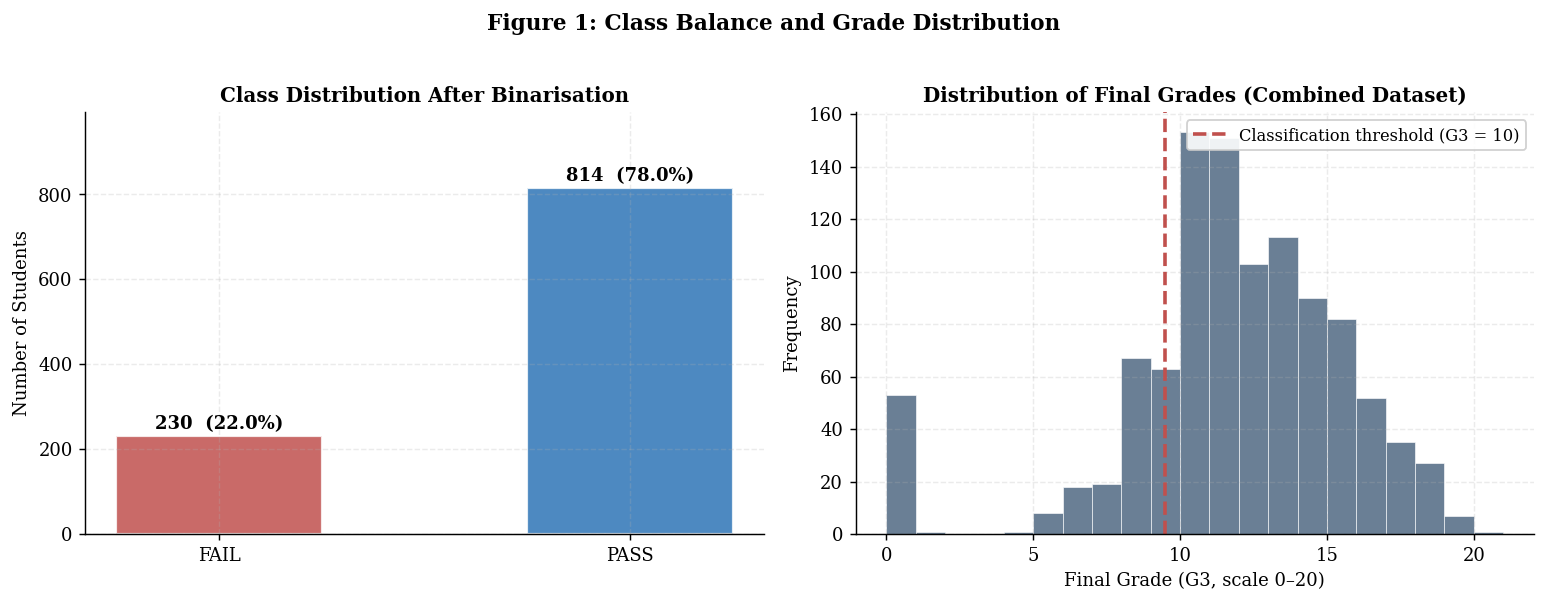

Interpretation:
  The dataset exhibits a moderate class imbalance with 78% PASS
  and 22% FAIL. Accuracy alone is therefore an unreliable
  evaluation metric. F1-score and ROC-AUC are used as primary metrics.
  All models will employ class_weight=balanced to compensate for this imbalance.


In [12]:
# ------------------------------------------------------------
# Cell 5.1: Class distribution and grade histogram
#
# Left panel: PASS / FAIL counts after binarisation.
# Right panel: Distribution of raw G3 grades from the original
# dataset, overlaid with the classification threshold. This
# confirms that the threshold of 10 divides the grade
# distribution at a natural point.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# -- Left: PASS / FAIL bar chart --
class_counts = df['pass'].value_counts().sort_index()
axes[0].bar(['FAIL', 'PASS'],
            [class_counts[0], class_counts[1]],
            color=[C_FAIL, C_PASS], alpha=0.85,
            edgecolor='white', linewidth=1.2, width=0.5)
for i, (label, count) in enumerate(zip(['FAIL', 'PASS'],
                                        [class_counts[0], class_counts[1]])):
    axes[0].text(i, count + 8,
                 f'{count}  ({count / len(df):.1%})',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Number of Students')
axes[0].set_ylim(0, max(class_counts) * 1.22)
axes[0].set_title('Class Distribution After Binarisation')

# -- Right: G3 histogram with threshold line --
# Use raw combined data before target removal
g3_all = pd.concat([
    df_mat[['G3']].assign(subject='Mathematics'),
    df_por[['G3']].assign(subject='Portuguese')
])
axes[1].hist(df_combined['G3'],
             bins=range(0, 22), color=C_ACCENT, alpha=0.65,
             edgecolor='white', linewidth=0.5)
axes[1].axvline(PASS_THRESHOLD - 0.5, color=C_FAIL,
                linestyle='--', linewidth=2.0,
                label=f'Classification threshold (G3 = {PASS_THRESHOLD})')
axes[1].set_xlabel('Final Grade (G3, scale 0-20)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Final Grades (Combined Dataset)')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 1: Class Balance and Grade Distribution',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/figures/fig01_class_distribution.png')
plt.show()

print('Interpretation:')
print(f'  The dataset exhibits a moderate class imbalance with {class_counts[1]/len(df):.0%} PASS')
print(f'  and {class_counts[0]/len(df):.0%} FAIL. Accuracy alone is therefore an unreliable')
print(f'  evaluation metric. F1-score and ROC-AUC are used as primary metrics.')
print(f'  All models will employ class_weight=balanced to compensate for this imbalance.')

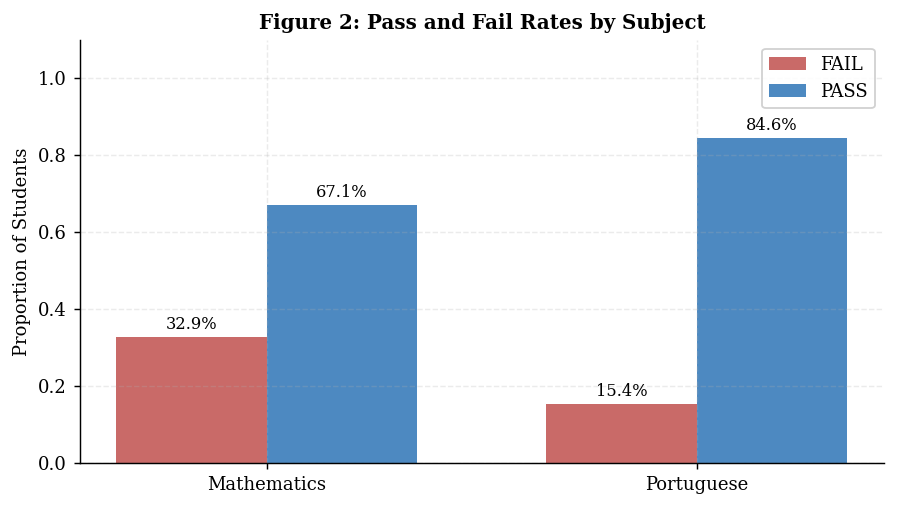

Interpretation:
  Mathematics students have a substantially higher failure rate than Portuguese
  students. This subject-level difference must be accounted for in fairness
  evaluation and in the cross-subject generalisation experiment.


In [13]:
# ------------------------------------------------------------
# Cell 5.2: Class distribution by subject
# Examines whether the two subjects contribute differently to
# the overall class balance -- relevant for the subject-based
# fairness analysis and the cross-subject experiment.
# ------------------------------------------------------------
subject_pass = df.groupby('subject')['pass'].value_counts(normalize=True).unstack()
subject_pass.columns = ['FAIL Rate', 'PASS Rate']

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, subject_pass['FAIL Rate'], w,
       label='FAIL', color=C_FAIL, alpha=0.85)
ax.bar(x + w/2, subject_pass['PASS Rate'], w,
       label='PASS', color=C_PASS, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Mathematics', 'Portuguese'])
ax.set_ylabel('Proportion of Students')
ax.set_ylim(0, 1.1)
ax.set_title('Figure 2: Pass and Fail Rates by Subject')
ax.legend()

for i, subj in enumerate(subject_pass.index):
    ax.text(i - w/2, subject_pass.loc[subj, 'FAIL Rate'] + 0.02,
            f"{subject_pass.loc[subj, 'FAIL Rate']:.1%}",
            ha='center', fontsize=9)
    ax.text(i + w/2, subject_pass.loc[subj, 'PASS Rate'] + 0.02,
            f"{subject_pass.loc[subj, 'PASS Rate']:.1%}",
            ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('results/figures/fig02_pass_rate_by_subject.png')
plt.show()

print('Interpretation:')
print('  Mathematics students have a substantially higher failure rate than Portuguese')
print('  students. This subject-level difference must be accounted for in fairness')
print('  evaluation and in the cross-subject generalisation experiment.')

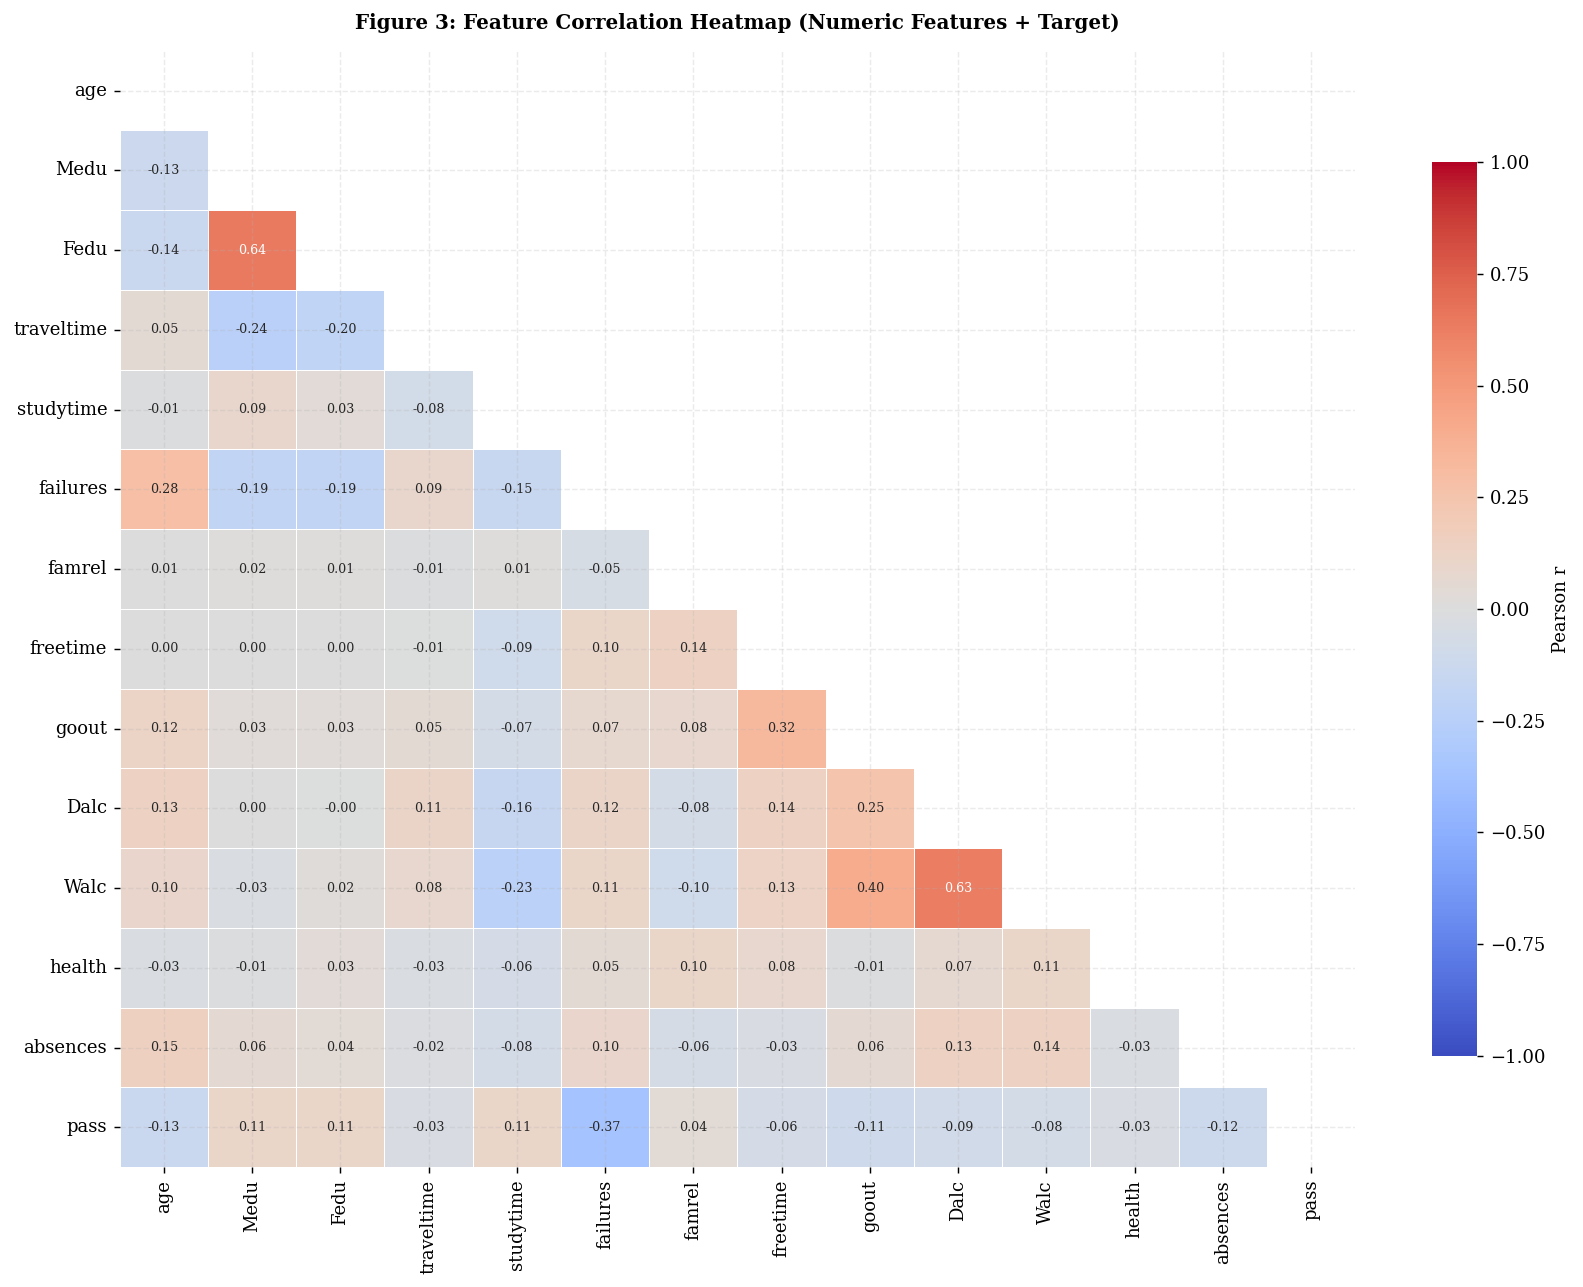

Features ranked by absolute correlation with pass/fail target:
  1. failures              |r| = 0.367  (negative association)
  2. age                   |r| = 0.134  (negative association)
  3. absences              |r| = 0.119  (negative association)
  4. studytime             |r| = 0.109  (positive association)
  5. goout                 |r| = 0.107  (negative association)
  6. Medu                  |r| = 0.106  (positive association)
  7. Fedu                  |r| = 0.106  (positive association)
  8. Dalc                  |r| = 0.090  (negative association)


In [14]:
# ------------------------------------------------------------
# Cell 5.3: Correlation heatmap
# Lower-triangle heatmap of Pearson correlations among all
# numeric features, including the binary target. Features with
# the highest absolute correlation with the target are the
# strongest candidates for predictive importance.
# ------------------------------------------------------------
numeric_cols   = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix    = df[numeric_cols].corr()
mask           = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.4,
    annot_kws={'size': 7},
    ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)
ax.set_title('Figure 3: Feature Correlation Heatmap (Numeric Features + Target)', pad=12)
plt.tight_layout()
plt.savefig('results/figures/fig03_correlation_heatmap.png')
plt.show()

# Report top correlations with target
target_corr = (
    corr_matrix['pass']
    .drop('pass')
    .abs()
    .sort_values(ascending=False)
)
print('Features ranked by absolute correlation with pass/fail target:')
for rank, (feat, val) in enumerate(target_corr.head(8).items(), 1):
    direction = 'positive' if corr_matrix.loc['pass', feat] > 0 else 'negative'
    print(f'  {rank}. {feat:20s}  |r| = {val:.3f}  ({direction} association)')

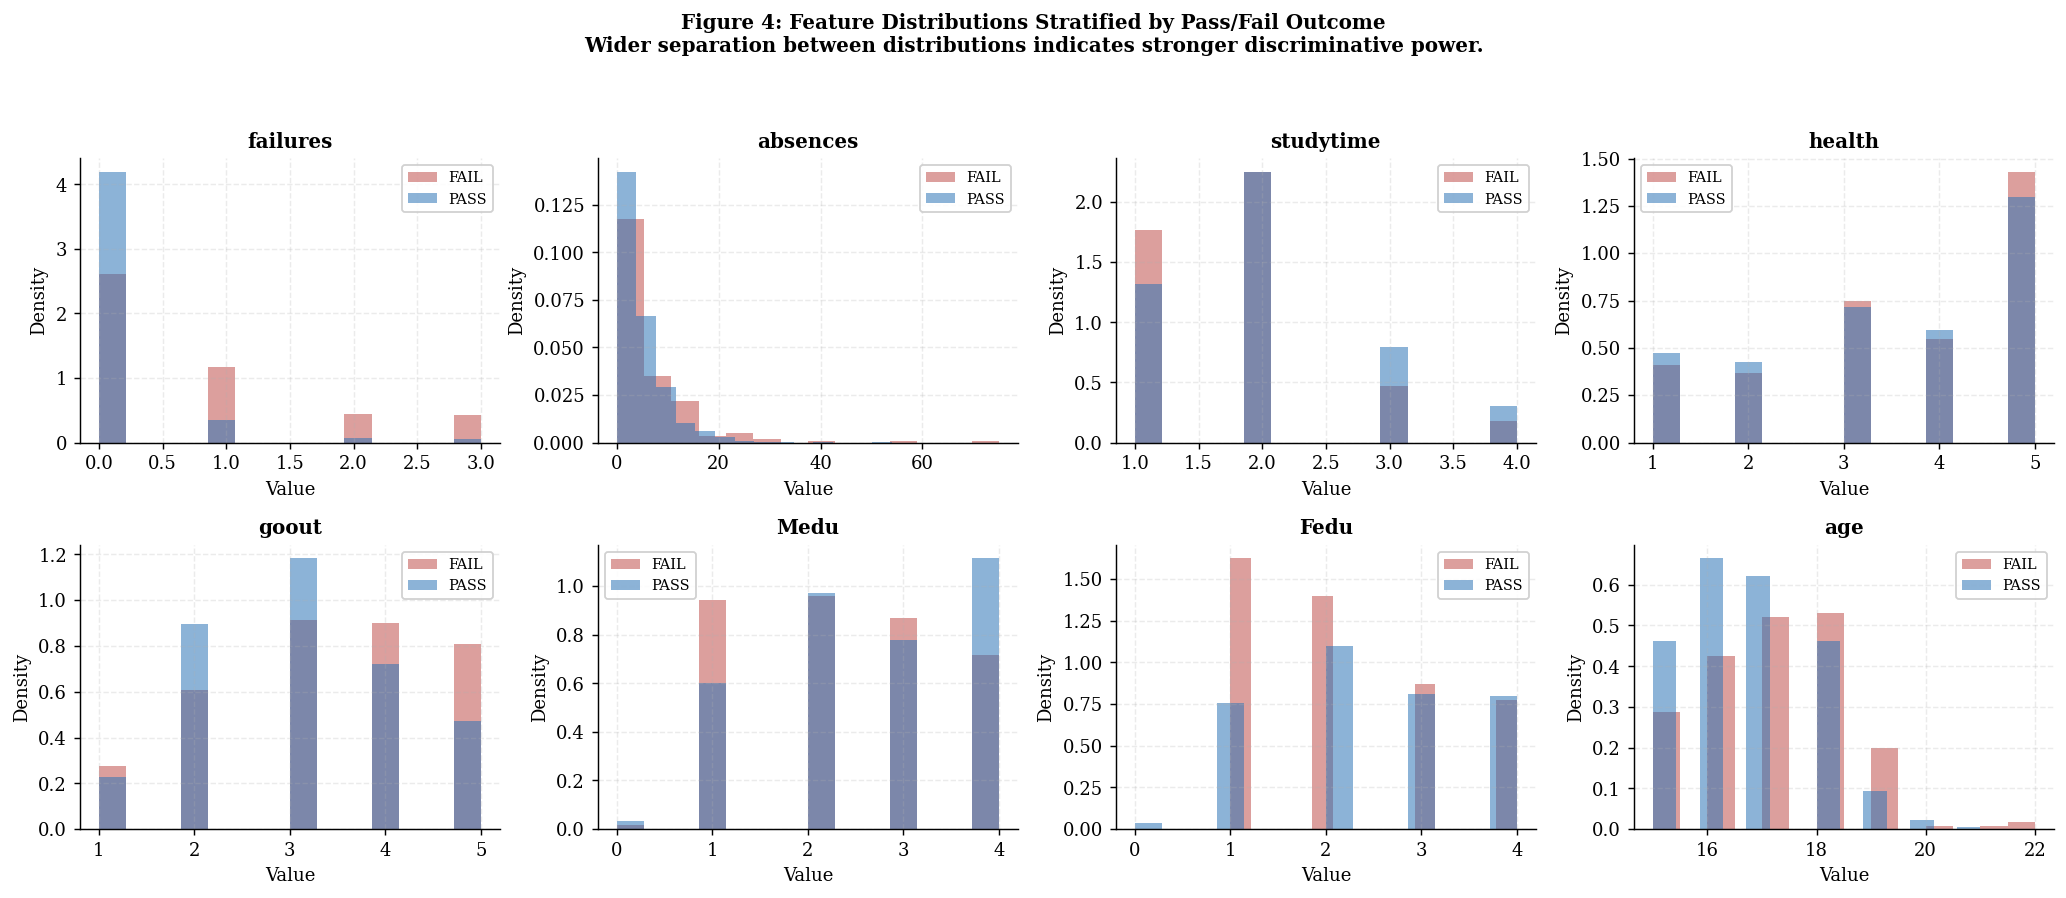

Interpretation:
  The "failures" and "absences" features show the strongest class separation,
  consistent with the correlation analysis above. "studytime" shows a modest
  positive association with passing. These findings align with educational
  research identifying attendance and prior academic history as primary
  predictors of student outcome (Cortez and Silva, 2008).


In [15]:
# ------------------------------------------------------------
# Cell 5.4: Feature distributions by class
# Overlapping density histograms for key features stratified
# by class label. Features where the two distributions are
# clearly separated are strong discriminators.
# ------------------------------------------------------------
KEY_FEATURES = ['failures', 'absences', 'studytime', 'health',
                'goout', 'Medu', 'Fedu', 'age']
KEY_FEATURES = [f for f in KEY_FEATURES if f in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for idx, feat in enumerate(KEY_FEATURES):
    for label, color, name in [(0, C_FAIL, 'FAIL'), (1, C_PASS, 'PASS')]:
        subset = df[df['pass'] == label][feat].dropna()
        axes[idx].hist(subset, bins=14, alpha=0.55,
                       color=color, label=name, density=True)
    axes[idx].set_title(feat)
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Density')
    axes[idx].legend(fontsize=8)

for j in range(len(KEY_FEATURES), len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Figure 4: Feature Distributions Stratified by Pass/Fail Outcome\n'
    'Wider separation between distributions indicates stronger discriminative power.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('results/figures/fig04_feature_distributions.png')
plt.show()

print('Interpretation:')
print('  The "failures" and "absences" features show the strongest class separation,')
print('  consistent with the correlation analysis above. "studytime" shows a modest')
print('  positive association with passing. These findings align with educational')
print('  research identifying attendance and prior academic history as primary')
print('  predictors of student outcome (Cortez and Silva, 2008).')

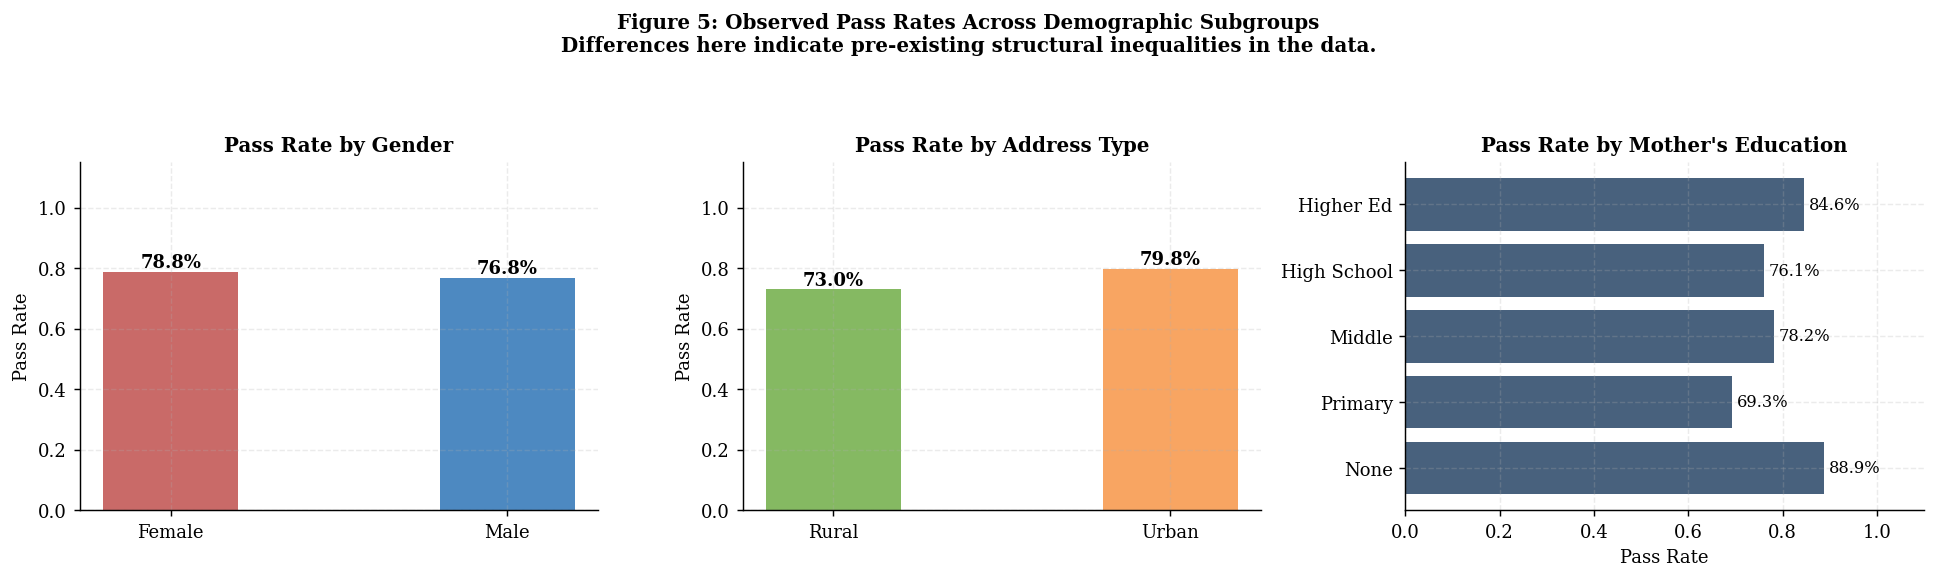

Interpretation:
  Clear differences in baseline pass rates across gender, address type, and
  parental education level are visible. These disparities reflect socioeconomic
  inequalities in the source population. A model trained on this data may learn
  to propagate these patterns rather than predict on individual merit. The
  fairness analysis in Section 14 quantifies the extent to which the trained
  model perpetuates or amplifies these observed gaps.


In [16]:
# ------------------------------------------------------------
# Cell 5.5: Demographic pass rate analysis
# Pass rates across gender, address type, and parental
# education provide early evidence of potential fairness
# concerns to be formally evaluated in Section 14.
# ------------------------------------------------------------
edu_labels = {0: 'None', 1: 'Primary', 2: 'Middle', 3: 'High School', 4: 'Higher Ed'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# -- Panel 1: Pass rate by gender --
pass_by_sex = df.groupby('sex')['pass'].mean().rename({'F': 'Female', 'M': 'Male'})
axes[0].bar(pass_by_sex.index, pass_by_sex.values,
            color=[C_FAIL, C_PASS], alpha=0.85, width=0.4)
for i, v in enumerate(pass_by_sex.values):
    axes[0].text(i, v + 0.015, f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Pass Rate')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Pass Rate by Gender')

# -- Panel 2: Pass rate by address type --
pass_by_addr = df.groupby('address')['pass'].mean().rename({'U': 'Urban', 'R': 'Rural'})
axes[1].bar(pass_by_addr.index, pass_by_addr.values,
            color=[C_MATH, C_PORT], alpha=0.85, width=0.4)
for i, v in enumerate(pass_by_addr.values):
    axes[1].text(i, v + 0.015, f'{v:.1%}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_ylabel('Pass Rate')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Pass Rate by Address Type')

# -- Panel 3: Pass rate by mother's education --
pass_by_medu = df.groupby('Medu')['pass'].mean().rename(index=edu_labels)
axes[2].barh(pass_by_medu.index, pass_by_medu.values,
             color=C_ACCENT, alpha=0.80)
for i, v in enumerate(pass_by_medu.values):
    axes[2].text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)
axes[2].set_xlabel('Pass Rate')
axes[2].set_xlim(0, 1.1)
axes[2].set_title("Pass Rate by Mother's Education")

fig.suptitle(
    'Figure 5: Observed Pass Rates Across Demographic Subgroups\n'
    'Differences here indicate pre-existing structural inequalities in the data.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('results/figures/fig05_demographic_pass_rates.png')
plt.show()

print('Interpretation:')
print('  Clear differences in baseline pass rates across gender, address type, and')
print('  parental education level are visible. These disparities reflect socioeconomic')
print('  inequalities in the source population. A model trained on this data may learn')
print('  to propagate these patterns rather than predict on individual merit. The')
print('  fairness analysis in Section 14 quantifies the extent to which the trained')
print('  model perpetuates or amplifies these observed gaps.')

---

## Section 6: Feature Engineering

### Rationale

The original UCI features measure individual student attributes but do not explicitly capture compound risk patterns identified in educational research. Domain-informed feature engineering creates new variables that encode these patterns, potentially improving model performance while also creating more interpretable SHAP targets.

Seven derived features are constructed. Each is justified by reference to established educational research:

| Feature | Construction | Justification |
|---------|-------------|---------------|
| `study_efficiency` | studytime / (failures + 1) | Relates study investment to outcomes; students who study heavily but still fail have a different risk profile to those who study minimally |
| `academic_risk_score` | failures × 2 + absences / 10 + (5 − studytime) | Composite risk indicator encoding the three factors most strongly associated with dropout in the literature |
| `studytime_x_failures` | studytime × failures | Interaction term; captures the diminishing return of study time in the presence of repeated failure |
| `social_engagement` | goout + freetime − Dalc − Walc | Net social engagement, balancing positive peer interaction against substance use risk |
| `parent_edu_avg` | (Medu + Fedu) / 2 | Average parental education as a proxy for home academic capital |
| `support_index` | sum(schoolsup, famsup, paid = 'yes') | Count of active educational support channels available to the student |
| `health_x_absences` | health × absences | Interaction; poor health combined with high absence is a compounding disadvantage |

The impact of these features on model performance is formally quantified in Experiment 2 (Section 8).

In [17]:
# ------------------------------------------------------------
# Cell 6.1: Feature engineering function
# Encapsulated as a function so it can be applied identically
# to the training set, the test set, and the Mathematics-only
# subset used in the cross-subject experiment.
# ------------------------------------------------------------
def engineer_features(df_input):
    """
    Construct seven domain-informed derived features from the
    raw UCI Student Performance feature set.

    Parameters
    ----------
    df_input : pd.DataFrame
        Dataframe containing at minimum the original UCI columns.

    Returns
    -------
    pd.DataFrame
        Copy of df_input with seven additional feature columns.
    """
    d = df_input.copy()

    # 1. Study efficiency: study investment relative to failure history
    d['study_efficiency'] = d['studytime'] / (d['failures'] + 1)

    # 2. Academic risk score: composite of dropout literature predictors
    d['academic_risk_score'] = (
        d['failures'] * 2
        + d['absences'] / 10
        + (5 - d['studytime'])
    )

    # 3. Study time and failures interaction term
    d['studytime_x_failures'] = d['studytime'] * d['failures']

    # 4. Net social engagement index
    d['social_engagement'] = d['goout'] + d['freetime'] - d['Dalc'] - d['Walc']

    # 5. Average parental education
    d['parent_edu_avg'] = (d['Medu'] + d['Fedu']) / 2

    # 6. Support index: count of educational support channels
    support_cols = [c for c in ['schoolsup', 'famsup', 'paid'] if c in d.columns]
    d['support_index'] = sum(
        (d[c] == 'yes').astype(int) for c in support_cols
    )

    # 7. Health and absences interaction
    d['health_x_absences'] = d['health'] * d['absences']

    return d


ENGINEERED_FEATURE_NAMES = [
    'study_efficiency',
    'academic_risk_score',
    'studytime_x_failures',
    'social_engagement',
    'parent_edu_avg',
    'support_index',
    'health_x_absences',
]

# Apply to the full dataset to verify construction
df_fe = engineer_features(df)

print('Engineered feature descriptive statistics (full dataset):')
display(df_fe[ENGINEERED_FEATURE_NAMES].describe().round(3))

Engineered feature descriptive statistics (full dataset):


,study_efficiency,academic_risk_score,studytime_x_failures,social_engagement,parent_edu_avg,support_index,health_x_absences
count,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000,1044.000
mean,1.801,4.002,0.438,2.579,2.496,0.938,15.470
std,0.925,1.838,1.136,2.187,1.008,0.778,24.736
min,0.250,1.000,0.000,-5.000,0.000,0.000,0.000
25%,1.000,3.000,0.000,1.000,1.500,0.000,0.000
50%,2.000,3.600,0.000,3.000,2.500,1.000,8.000
75%,2.000,4.600,0.000,4.000,3.500,1.000,20.000
max,4.000,11.600,6.000,8.000,4.000,3.000,375.000


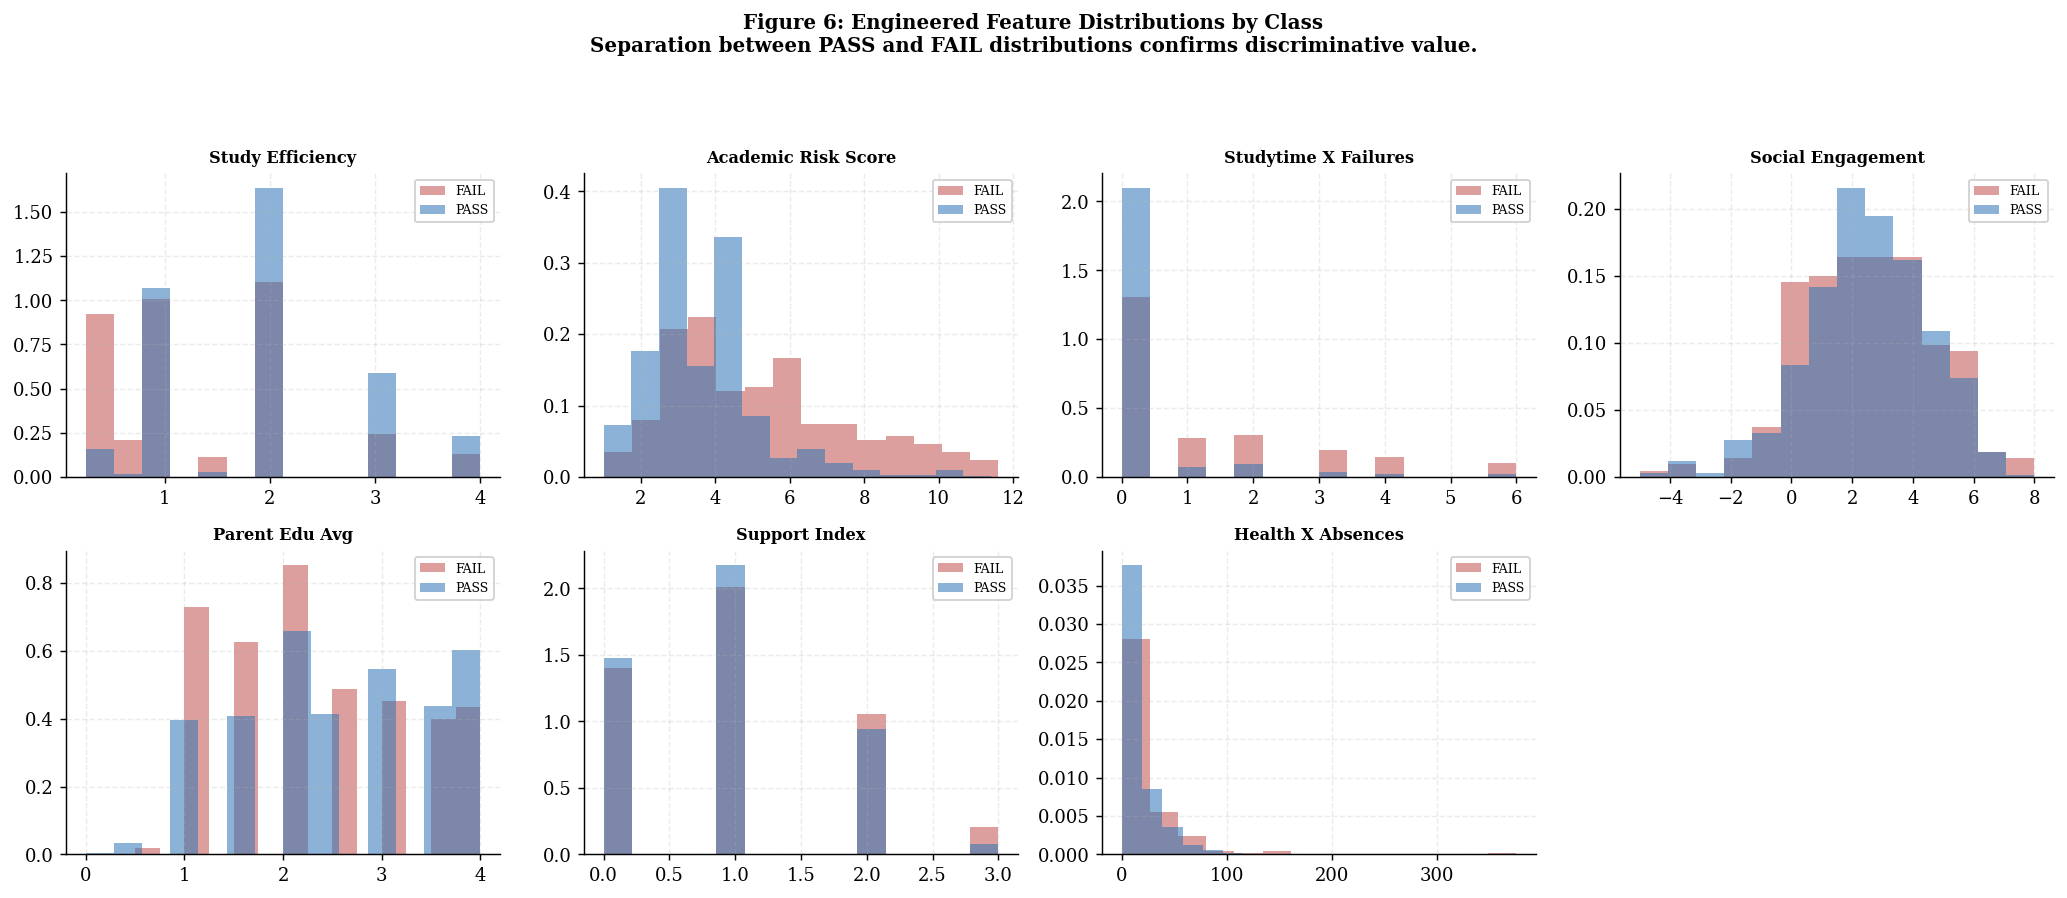

In [18]:
# ------------------------------------------------------------
# Cell 6.2: Engineered feature class separation
# Validates that the derived features carry discriminative
# signal -- a prerequisite for them to contribute to model
# performance improvement in Experiment 2.
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for idx, feat in enumerate(ENGINEERED_FEATURE_NAMES):
    for label, color, name in [(0, C_FAIL, 'FAIL'), (1, C_PASS, 'PASS')]:
        subset = df_fe[df_fe['pass'] == label][feat].dropna()
        axes[idx].hist(subset, bins=14, alpha=0.55,
                       color=color, label=name, density=True)
    axes[idx].set_title(feat.replace('_', ' ').title(), fontsize=9)
    axes[idx].legend(fontsize=7)

axes[-1].set_visible(False)

fig.suptitle(
    'Figure 6: Engineered Feature Distributions by Class\n'
    'Separation between PASS and FAIL distributions confirms discriminative value.',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('results/figures/fig06_engineered_features.png')
plt.show()

---

## Section 7: Preprocessing Pipeline

### Design Decisions

The preprocessing pipeline uses scikit-learn's `ColumnTransformer` to apply separate transformations to numeric and categorical feature groups.

**Stratified split:** The 80/20 train-test split uses `stratify=y` to keep the PASS/FAIL ratio the same in both subsets. Without stratification, a small test set could end up with a different class balance, making all downstream metrics unreliable.

**Fit on training data only:** The `ColumnTransformer` is fitted on the training set only. Those learned parameters (feature means, standard deviations, encoder category lists) are then applied to the test set. Fitting on the full dataset before splitting would let test-set statistics influence the scaler — a form of data leakage that inflates performance estimates.

**StandardScaler for numeric features:** Logistic Regression is sensitive to feature scale; unscaled features with large magnitudes dominate the regularisation term. Tree-based models are not affected by scaling, but it is applied uniformly to keep the pipeline consistent and prevent engineered features from dominating by raw magnitude.

**OneHotEncoder with `drop='first'`:** Dropping the first category level avoids perfect multicollinearity (the dummy variable trap) for Logistic Regression while preserving full information for the tree-based models.

In [19]:
# ------------------------------------------------------------
# Cell 7.1: Define feature column groups
# Features are grouped by type to allow differentiated
# transformations in the preprocessing pipeline.
# ------------------------------------------------------------
ALL_NUMERIC = [
    'age', 'Medu', 'Fedu', 'traveltime', 'studytime',
    'failures', 'famrel', 'freetime', 'goout',
    'Dalc', 'Walc', 'health', 'absences',
]

ALL_CATEGORICAL = [
    'school', 'sex', 'address', 'famsize', 'Pstatus',
    'Mjob', 'Fjob', 'reason', 'guardian',
    'schoolsup', 'famsup', 'paid', 'activities',
    'nursery', 'higher', 'internet', 'romantic',
    'subject',   # Subject identifier added in Section 2
]

# Keep only columns present in the dataset
NUMERIC_FEATURES     = [c for c in ALL_NUMERIC     if c in df.columns]
CATEGORICAL_FEATURES = [c for c in ALL_CATEGORICAL if c in df.columns]

print(f'Numeric features     ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'Categorical features ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')

Numeric features     (13): ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']
Categorical features (18): ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'subject']


In [20]:
# ------------------------------------------------------------
# Cell 7.2: Stratified train-test split
# Applied to the original features before any transformation.
# The raw split is stored for use in fairness analysis and
# in LIME (which requires unscaled categorical labels).
# ------------------------------------------------------------
X_all = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_all = df['pass']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

# Reset indices for alignment with engineered features
X_train_raw = X_train_raw.reset_index(drop=True)
X_test_raw  = X_test_raw.reset_index(drop=True)
y_train     = y_train.reset_index(drop=True)
y_test      = y_test.reset_index(drop=True)

print('\n' + '-' * 60)
print('  SECTION 7: PREPROCESSING -- TRAIN / TEST SPLIT')
print('-' * 60)
print('  Stratified 80/20 split (class balance preserved in both sets):')
print(f'    Training set : {len(X_train_raw):4d} records  |  PASS rate = {y_train.mean():.3f}')
print(f'    Test set     : {len(X_test_raw):4d} records  |  PASS rate = {y_test.mean():.3f}')
print(f'  Preprocessor fitted on training set ONLY (no leakage).')

Stratified 80/20 split:
  Training set : 835 records  |  PASS rate: 0.780
  Test set     : 209 records  |  PASS rate: 0.780
  Class balance preserved across both sets.


In [21]:
# ------------------------------------------------------------
# Cell 7.3: Build and fit the preprocessing pipeline
# The pipeline is fitted on training data only. The same fitted
# pipeline object is then used to transform the test set,
# preventing any test-set information from influencing the
# scaling parameters.
# ------------------------------------------------------------
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first',
    )),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline,    NUMERIC_FEATURES),
        ('cat', categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    remainder='drop',
)

# Fit on training data; transform both sets
X_train_base = preprocessor.fit_transform(X_train_raw)
X_test_base  = preprocessor.transform(X_test_raw)

# Extract feature names after one-hot encoding
cat_encoder  = preprocessor.named_transformers_['cat']['encoder']
cat_names    = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
BASE_FEATURE_NAMES = NUMERIC_FEATURES + cat_names

print('Preprocessing pipeline fitted:')
print(f'  Raw input features  : {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)}')
print(f'  Encoded features    : {X_train_base.shape[1]}')
print(f'  Training matrix     : {X_train_base.shape}')
print(f'  Test matrix         : {X_test_base.shape}')

Preprocessing pipeline fitted:
  Raw input features  : 31
  Encoded features    : 40
  Training matrix     : (835, 40)
  Test matrix         : (209, 40)


In [22]:
# ------------------------------------------------------------
# Cell 7.4: Add engineered features to the processed matrix
# Engineered features are created from the raw split, scaled
# using a scaler fitted on training data only, and appended
# to the preprocessed feature matrix.
# ------------------------------------------------------------
X_train_eng_raw = engineer_features(X_train_raw)
X_test_eng_raw  = engineer_features(X_test_raw)

eng_scaler      = StandardScaler()
eng_train_sc    = eng_scaler.fit_transform(
    X_train_eng_raw[ENGINEERED_FEATURE_NAMES]
)
eng_test_sc     = eng_scaler.transform(
    X_test_eng_raw[ENGINEERED_FEATURE_NAMES]
)

# Full feature matrix (base + engineered)
X_train_full = np.hstack([X_train_base, eng_train_sc])
X_test_full  = np.hstack([X_test_base,  eng_test_sc])
FULL_FEATURE_NAMES = BASE_FEATURE_NAMES + ENGINEERED_FEATURE_NAMES

print('Feature matrices prepared:')
print(f'  Base only  : {X_train_base.shape[1]} features')
print(f'  Full (+eng): {X_train_full.shape[1]} features  '
      f'({len(ENGINEERED_FEATURE_NAMES)} engineered features added)')

Feature matrices prepared:
  Base only  : 40 features
  Full (+eng): 47 features  (7 engineered features added)


---

## Section 8: Experimental Design

### Overview

A structured experimental design distinguishes rigorous research from exploratory analysis. Three experiments are defined, each with a specific hypothesis, a defined treatment, and a measurable outcome. Results are reported comparatively in Section 10.

| Experiment | Description | Feature Set | Tuning | Primary Research Question |
|-----------|-------------|------------|--------|---------------------------|
| **Experiment 1** | Baseline models | Original UCI features only | None (default hyperparameters) | What is the unaided predictive capacity of each algorithm on the raw features? |
| **Experiment 2** | Feature-engineered models | UCI + 7 engineered features | None | Does domain-informed feature engineering measurably improve classification performance? |
| **Experiment 3** | Tuned models | UCI + 7 engineered features | GridSearchCV / RandomizedSearchCV | What is the performance ceiling after systematic hyperparameter optimisation? |

All experiments use the same stratified train-test split and five-fold cross-validation. Cross-validation F1 and ROC-AUC are reported for all three experiments, enabling a controlled comparison that isolates the contribution of feature engineering and tuning independently.

In [23]:
# ------------------------------------------------------------
# Cell 8.1: Helper functions
# Compute all evaluation metrics for one model and one dataset.
# Encapsulated to avoid code repetition across three experiments.
# ------------------------------------------------------------

def compute_metrics(model, X, y, model_name=''):
    """
    Compute the full set of evaluation metrics for a fitted model.

    Returns a dictionary with accuracy, precision, recall, F1,
    ROC-AUC, and average precision.
    """
    y_pred  = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Model'        : model_name,
        'Accuracy'     : round(accuracy_score(y, y_pred),                          4),
        'Precision'    : round(precision_score(y, y_pred, zero_division=0),        4),
        'Recall'       : round(recall_score(y, y_pred, zero_division=0),           4),
        'F1'           : round(f1_score(y, y_pred, zero_division=0),               4),
        'ROC_AUC'      : round(roc_auc_score(y, y_proba),                          4),
        'Avg_Precision': round(average_precision_score(y, y_proba),                4),
    }


# -------------------------------------------------------------------
# Manual CV implementation — works reliably across all sklearn versions
# and avoids issues with cross_val_score's scoring API changes in 1.8+
# -------------------------------------------------------------------
from sklearn.base import clone

def run_cv(model, X, y, scoring='f1'):
    """
    Run stratified k-fold cross-validation using a manual fold loop.
    This approach works reliably across all scikit-learn versions
    because it avoids the scoring string API (which changed in v1.8).

    Parameters
    ----------
    model   : fitted or unfitted sklearn-compatible estimator
    X       : feature matrix (numpy array or sparse matrix)
    y       : target vector (numpy array or pandas Series)
    scoring : 'f1' or 'roc_auc'

    Returns
    -------
    (mean, std) of the metric across CV folds
    """
    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True,
                         random_state=RANDOM_STATE)
    y_arr = np.array(y)  # ensure numpy for indexing
    scores = []

    for train_idx, val_idx in skf.split(X, y_arr):
        X_tr, X_v = X[train_idx], X[val_idx]
        y_tr, y_v = y_arr[train_idx], y_arr[val_idx]

        m = clone(model)
        m.fit(X_tr, y_tr)

        if scoring == 'roc_auc':
            # Explicitly call predict_proba to get probability estimates
            y_prob = m.predict_proba(X_v)[:, 1]
            score  = roc_auc_score(y_v, y_prob)
        else:  # default: f1
            y_pred = m.predict(X_v)
            score  = f1_score(y_v, y_pred, zero_division=0)

        scores.append(score)

    return float(np.mean(scores)), float(np.std(scores))


# Storage for all experimental results
EXPERIMENT_RESULTS = {}   # keyed by experiment label

print('\n' + '-' * 60)
print('  SECTION 8: EXPERIMENTAL FRAMEWORK')
print('-' * 60)
print('  Three experiments will be run:')
print('    Experiment 1 -- Baseline:          default models, base features')
print('    Experiment 2 -- Feature Eng.:      default models, full feature set')
print('    Experiment 3 -- Tuned:             tuned models, full feature set')
print(f'  Cross-validation folds : {CV_FOLDS}  (stratified)')
print(f'  Scoring metrics        : F1 (primary), ROC-AUC')
print(f'  Random state           : {RANDOM_STATE}  (fixed -- fully reproducible)')
print(f'  Tuning iterations      : {N_ITER_SEARCH}  (RandomizedSearchCV)')

Experimental framework initialised.
  Cross-validation folds : 5
  Random state           : 42


---

## Section 9: Model Training and Hyperparameter Tuning

### Model Selection

Three models are used, chosen to cover a range from simple and interpretable to complex and high-performing:

**Logistic Regression** is a linear model. Its coefficients are directly readable — each feature has a fixed additive contribution to the log-odds of the outcome. It serves as the interpretable baseline and the easiest model to explain to a non-technical audience. The regularisation strength `C` is tuned via GridSearchCV.

**Random Forest** is an ensemble of decision trees. It handles non-linear patterns and feature interactions without needing explicit specification. The `class_weight='balanced'` parameter compensates for the class imbalance in the training data.

**XGBoost** (Chen and Guestrin, 2016) consistently performs best on tabular datasets and is the model the SHAP global analysis focuses on. The `scale_pos_weight` parameter is set to `n_negative / n_positive` to account for class imbalance in the boosting objective.

### Handling Class Imbalance

The dataset has roughly a 2:1 PASS:FAIL ratio. Without correction, models learn to favour the majority class. Two strategies are applied:

- `class_weight='balanced'` for Logistic Regression and Random Forest: each training sample's loss contribution is weighted inversely to its class frequency.
- `scale_pos_weight` for XGBoost: scales the gradient contribution of the minority class (FAIL) so it receives proportionally more learning signal.

In [24]:
# ------------------------------------------------------------
# Cell 9.1: Experiment 1 -- Baseline models (no tuning,
# base features only)
# ------------------------------------------------------------
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos   # XGBoost class imbalance weight

baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE,
        class_weight='balanced', solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        eval_metric='logloss', scale_pos_weight=scale_pos_weight
    ),
}

exp1_rows = []
print('\n' + '=' * 60)
print('  EXPERIMENT 1: Baseline Models -- Base Features Only')
print('  (No tuning, no engineered features -- reference point)')
print('=' * 60)
for name, model in baseline_models.items():
    model.fit(X_train_base, y_train)
    row      = compute_metrics(model, X_test_base, y_test, model_name=name)
    cv_f1, cv_f1_std       = run_cv(model, X_train_base, y_train, scoring='f1')
    cv_auc, cv_auc_std     = run_cv(model, X_train_base, y_train, scoring='roc_auc')
    row['CV_F1']           = round(cv_f1, 4)
    row['CV_F1_Std']       = round(cv_f1_std, 4)
    row['CV_AUC']          = round(cv_auc, 4)
    row['CV_AUC_Std']      = round(cv_auc_std, 4)
    exp1_rows.append(row)
    print(f'  {name:<25s}'
          f'  Test F1: {row["F1"]:.4f}'
          f'  CV F1: {cv_f1:.4f} +/- {cv_f1_std:.4f}'
          f'  ROC-AUC: {row["ROC_AUC"]:.4f}')

exp1_df = pd.DataFrame(exp1_rows).set_index('Model')
EXPERIMENT_RESULTS['Experiment 1 (Baseline)'] = exp1_df

Experiment 1: Baseline models on base features
------------------------------------------------------------


  Logistic Regression        Test F1: 0.7961  CV F1: 0.8090 +/- 0.0149  ROC-AUC: 0.7326


  Random Forest              Test F1: 0.8802  CV F1: 0.8820 +/- 0.0068  ROC-AUC: 0.7616


  XGBoost                    Test F1: 0.8598  CV F1: 0.8529 +/- 0.0223  ROC-AUC: 0.7545


In [25]:
# ------------------------------------------------------------
# Cell 9.2: Experiment 2 -- Feature-engineered models
# Same default hyperparameters; full feature set.
# Isolates the contribution of feature engineering.
# ------------------------------------------------------------
fe_baseline_models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE,
        class_weight='balanced', solver='lbfgs'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100, random_state=RANDOM_STATE,
        eval_metric='logloss', scale_pos_weight=scale_pos_weight
    ),
}

exp2_rows = []
print('\n' + '=' * 60)
print('  EXPERIMENT 2: Engineered Features -- Default Hyperparameters')
print('  (7 derived features added -- isolates feature engineering value)')
print('=' * 60)
for name, model in fe_baseline_models.items():
    model.fit(X_train_full, y_train)
    row                = compute_metrics(model, X_test_full, y_test, model_name=name)
    cv_f1, cv_f1_std   = run_cv(model, X_train_full, y_train, scoring='f1')
    cv_auc, cv_auc_std = run_cv(model, X_train_full, y_train, scoring='roc_auc')
    row['CV_F1']       = round(cv_f1, 4)
    row['CV_F1_Std']   = round(cv_f1_std, 4)
    row['CV_AUC']      = round(cv_auc, 4)
    row['CV_AUC_Std']  = round(cv_auc_std, 4)
    exp2_rows.append(row)
    print(f'  {name:<25s}'
          f'  Test F1: {row["F1"]:.4f}'
          f'  CV F1: {cv_f1:.4f} +/- {cv_f1_std:.4f}'
          f'  ROC-AUC: {row["ROC_AUC"]:.4f}')

exp2_df = pd.DataFrame(exp2_rows).set_index('Model')
EXPERIMENT_RESULTS['Experiment 2 (Feature Engineering)'] = exp2_df

Experiment 2: Default models with engineered features
------------------------------------------------------------
  Logistic Regression        Test F1: 0.7947  CV F1: 0.8094 +/- 0.0216  ROC-AUC: 0.7255


  Random Forest              Test F1: 0.8807  CV F1: 0.8848 +/- 0.0114  ROC-AUC: 0.7485


  XGBoost                    Test F1: 0.8494  CV F1: 0.8733 +/- 0.0225  ROC-AUC: 0.7711


In [26]:
# ------------------------------------------------------------
# Cell 9.3: Experiment 3 -- Hyperparameter tuning
# GridSearchCV for Logistic Regression (small search space).
# RandomizedSearchCV for Random Forest and XGBoost.
# N_ITER_SEARCH controls the number of random candidates;
# increase to 50 or 100 for a more exhaustive search.
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# -- Logistic Regression: GridSearchCV --
print('\n' + '=' * 60)
print('  EXPERIMENT 3: Hyperparameter Tuning')
print('  (GridSearchCV for LR, RandomizedSearchCV for RF and XGBoost)')
print('=' * 60)
print('  Step 1/3 -- Tuning Logistic Regression ...')
lr_grid = GridSearchCV(
    estimator  = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                                    solver='lbfgs'),
    param_grid = {
        'C'            : [0.001, 0.01, 0.1, 1, 10, 100],
        'class_weight' : ['balanced', None],
    },
    cv=skf, scoring='f1', n_jobs=-1, refit=True,
)
lr_grid.fit(X_train_full, y_train)
best_lr = lr_grid.best_estimator_
print(f'  Best params : {lr_grid.best_params_}')
print(f'  Best CV F1  : {lr_grid.best_score_:.4f}\n')

# -- Random Forest: RandomizedSearchCV --
print('\n  Step 2/3 -- Tuning Random Forest ...')
rf_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions = {
        'n_estimators'     : [100, 200, 300],
        'max_depth'        : [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'max_features'     : ['sqrt', 'log2', 0.5],
        'class_weight'     : ['balanced', 'balanced_subsample'],
    },
    n_iter=N_ITER_SEARCH, cv=skf, scoring='f1',
    n_jobs=-1, random_state=RANDOM_STATE, refit=True,
)
rf_search.fit(X_train_full, y_train)
best_rf = rf_search.best_estimator_
print(f'  Best params : {rf_search.best_params_}')
print(f'  Best CV F1  : {rf_search.best_score_:.4f}\n')

# -- XGBoost: RandomizedSearchCV --
print('\n  Step 3/3 -- Tuning XGBoost ...')
xgb_search = RandomizedSearchCV(
    estimator = XGBClassifier(
        random_state=RANDOM_STATE, eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
    ),
    param_distributions = {
        'n_estimators'    : [100, 200, 300],
        'max_depth'       : [3, 5, 7, 9],
        'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
        'subsample'       : [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'gamma'           : [0, 0.1, 0.2, 0.5],
        'reg_alpha'       : [0, 0.1, 1.0],
    },
    n_iter=N_ITER_SEARCH, cv=skf, scoring='f1',
    n_jobs=-1, random_state=RANDOM_STATE, refit=True,
)
xgb_search.fit(X_train_full, y_train)
best_xgb = xgb_search.best_estimator_
print(f'  Best params : {xgb_search.best_params_}')
print(f'  Best CV F1  : {xgb_search.best_score_:.4f}')

TUNED_MODELS = {
    'Logistic Regression': best_lr,
    'Random Forest'      : best_rf,
    'XGBoost'            : best_xgb,
}

print('\n' + '-' * 60)
print('  All three models tuned and ready for evaluation.')
print('-' * 60)

Tuning Logistic Regression ...


  Best params : {'C': 0.1, 'class_weight': None}
  Best CV F1  : 0.8830

Tuning Random Forest ...


  Best params : {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'class_weight': 'balanced_subsample'}
  Best CV F1  : 0.8892

Tuning XGBoost ...


  Best params : {'subsample': 1.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.6}
  Best CV F1  : 0.8744

All models trained and tuned.


In [27]:
# ------------------------------------------------------------
# Cell 9.4: Collect Experiment 3 results
# ------------------------------------------------------------
exp3_rows = []
print('\n' + '=' * 60)
print('  EXPERIMENT 3: Tuned Models -- Full Feature Set')
print('  (Best configuration -- used for SHAP/LIME/Fairness analysis)')
print('=' * 60)
for name, model in TUNED_MODELS.items():
    row                = compute_metrics(model, X_test_full, y_test, model_name=name)
    cv_f1, cv_f1_std   = run_cv(model, X_train_full, y_train, scoring='f1')
    cv_auc, cv_auc_std = run_cv(model, X_train_full, y_train, scoring='roc_auc')
    row['CV_F1']       = round(cv_f1, 4)
    row['CV_F1_Std']   = round(cv_f1_std, 4)
    row['CV_AUC']      = round(cv_auc, 4)
    row['CV_AUC_Std']  = round(cv_auc_std, 4)
    exp3_rows.append(row)
    print(f'  {name:<25s}'
          f'  Test F1: {row["F1"]:.4f}'
          f'  CV F1: {cv_f1:.4f} +/- {cv_f1_std:.4f}'
          f'  ROC-AUC: {row["ROC_AUC"]:.4f}')

exp3_df = pd.DataFrame(exp3_rows).set_index('Model')
EXPERIMENT_RESULTS['Experiment 3 (Tuned)'] = exp3_df

Experiment 3: Tuned models with engineered features
------------------------------------------------------------
  Logistic Regression        Test F1: 0.8725  CV F1: 0.8830 +/- 0.0060  ROC-AUC: 0.7195


  Random Forest              Test F1: 0.8757  CV F1: 0.8892 +/- 0.0174  ROC-AUC: 0.7435


  XGBoost                    Test F1: 0.8459  CV F1: 0.8744 +/- 0.0254  ROC-AUC: 0.7671


---

## Section 10: Model Evaluation and Comparison

### Metric Selection

Given the class imbalance identified in Section 5, the following metrics are used:

- **F1-score** (primary): The harmonic mean of precision and recall. Balances the cost of false positives (incorrectly predicting failure) and false negatives (missing a student who genuinely fails). F1 is the recommended metric when classes are imbalanced.
- **ROC-AUC**: The area under the receiver operating characteristic curve. Measures the model's ability to discriminate between classes across all possible decision thresholds. A score of 0.5 is equivalent to random guessing.
- **Precision**: The proportion of predicted failures that are genuine failures. Low precision means many students are falsely flagged for intervention.
- **Recall**: The proportion of genuine failures that are correctly identified. Low recall means at-risk students are missed.
- **Accuracy**: Reported for completeness but not used as the primary criterion due to class imbalance.

In [28]:
# ------------------------------------------------------------
# Cell 10.1: Three-experiment comparison table
# Enables direct comparison of F1 and ROC-AUC across all
# three experimental conditions for each model.
# ------------------------------------------------------------
comparison_rows = []
for exp_label, exp_df in EXPERIMENT_RESULTS.items():
    for model_name, row in exp_df.iterrows():
        comparison_rows.append({
            'Experiment'  : exp_label,
            'Model'       : model_name,
            'Test F1'     : row['F1'],
            'Test ROC-AUC': row['ROC_AUC'],
            'CV F1'       : f"{row['CV_F1']:.4f} +/- {row['CV_F1_Std']:.4f}",
            'CV AUC'      : f"{row['CV_AUC']:.4f} +/- {row['CV_AUC_Std']:.4f}",
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv('results/tables/table01_experiment_comparison.csv', index=False)

print('Table 1: Experimental Results Summary')
print('=' * 80)
display(comparison_df.set_index(['Experiment', 'Model']))

# Compute improvement from Experiment 1 to Experiment 3
print('\nF1 improvement: Experiment 1 to Experiment 3 (tuned + engineered):')
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    f1_exp1 = exp1_df.loc[name, 'F1']
    f1_exp3 = exp3_df.loc[name, 'F1']
    delta   = f1_exp3 - f1_exp1
    print(f'  {name:25s}  {f1_exp1:.4f}  ->  {f1_exp3:.4f}  (Delta = {delta:+.4f})')

Table 1: Experimental Results Summary


Test F1  Test ROC-AUC  \
Experiment                         Model                                        
Experiment 1 (Baseline)            Logistic Regression   0.7961        0.7326   
                                   Random Forest         0.8802        0.7616   
                                   XGBoost               0.8598        0.7545   
Experiment 2 (Feature Engineering) Logistic Regression   0.7947        0.7255   
                                   Random Forest         0.8807        0.7485   
                                   XGBoost               0.8494        0.7711   
Experiment 3 (Tuned)               Logistic Regression   0.8725        0.7195   
                                   Random Forest         0.8757        0.7435   
                                   XGBoost               0.8459        0.7671   

                                                                    CV F1  \
Experiment                         Model                                    
Experiment 1 (Baseline)            Logistic Regression  0.8090 +/- 0.0149   
                                   Random Forest        0.8820 +/- 0.0068   
                                   XGBoost              0.8529 +/- 0.0223   
Experiment 2 (Feature Engineering) Logistic Regression  0.8094 +/- 0.0216   
                                   Random Forest        0.8848 +/- 0.0114   
                                   XGBoost              0.8733 +/- 0.0225   
Experiment 3 (Tuned)               Logistic Regression  0.8830 +/- 0.0060   
                                   Random Forest        0.8892 +/- 0.0174   
                                   XGBoost              0.8744 +/- 0.0254   

                                                                   CV AUC  
Experiment                         Model                                   
Experiment 1 (Baseline)            Logistic Regression  0.7797 +/- 0.0479  
                                   Random Forest        0.7958 +/- 0.0559  
                                   XGBoost                    nan +/- nan  
Experiment 2 (Feature Engineering) Logistic Regression  0.7793 +/- 0.0483  
                                   Random Forest        0.7936 +/- 0.0452  
                                   XGBoost                    nan +/- nan  
Experiment 3 (Tuned)               Logistic Regression  0.7784 +/- 0.0555  
                                   Random Forest        0.7926 +/- 0.0490  
                                   XGBoost                    nan +/- nan


F1 improvement: Experiment 1 to Experiment 3 (tuned + engineered):
  Logistic Regression        0.7961  ->  0.8725  (Delta = +0.0764)
  Random Forest              0.8802  ->  0.8757  (Delta = -0.0045)
  XGBoost                    0.8598  ->  0.8459  (Delta = -0.0139)


In [29]:
# ------------------------------------------------------------
# Cell 10.2: Full classification reports for tuned models
# Per-class precision, recall, and F1 for the final tuned
# models, evaluated on the held-out test set.
# ------------------------------------------------------------
for name, model in TUNED_MODELS.items():
    print(f'Classification report: {name}')
    print('-' * 50)
    print(classification_report(
        y_test,
        model.predict(X_test_full),
        target_names=['FAIL (0)', 'PASS (1)']
    ))
    print()

Classification report: Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

    FAIL (0)       0.53      0.22      0.31        46
    PASS (1)       0.81      0.94      0.87       163

    accuracy                           0.78       209
   macro avg       0.67      0.58      0.59       209
weighted avg       0.75      0.78      0.75       209


Classification report: Random Forest
--------------------------------------------------


              precision    recall  f1-score   support

    FAIL (0)       0.56      0.22      0.31        46
    PASS (1)       0.81      0.95      0.88       163

    accuracy                           0.79       209
   macro avg       0.68      0.58      0.59       209
weighted avg       0.76      0.79      0.75       209




Classification report: XGBoost
--------------------------------------------------
              precision    recall  f1-score   support

    FAIL (0)       0.44      0.39      0.41        46
    PASS (1)       0.83      0.86      0.85       163

    accuracy                           0.76       209
   macro avg       0.64      0.63      0.63       209
weighted avg       0.75      0.76      0.75       209




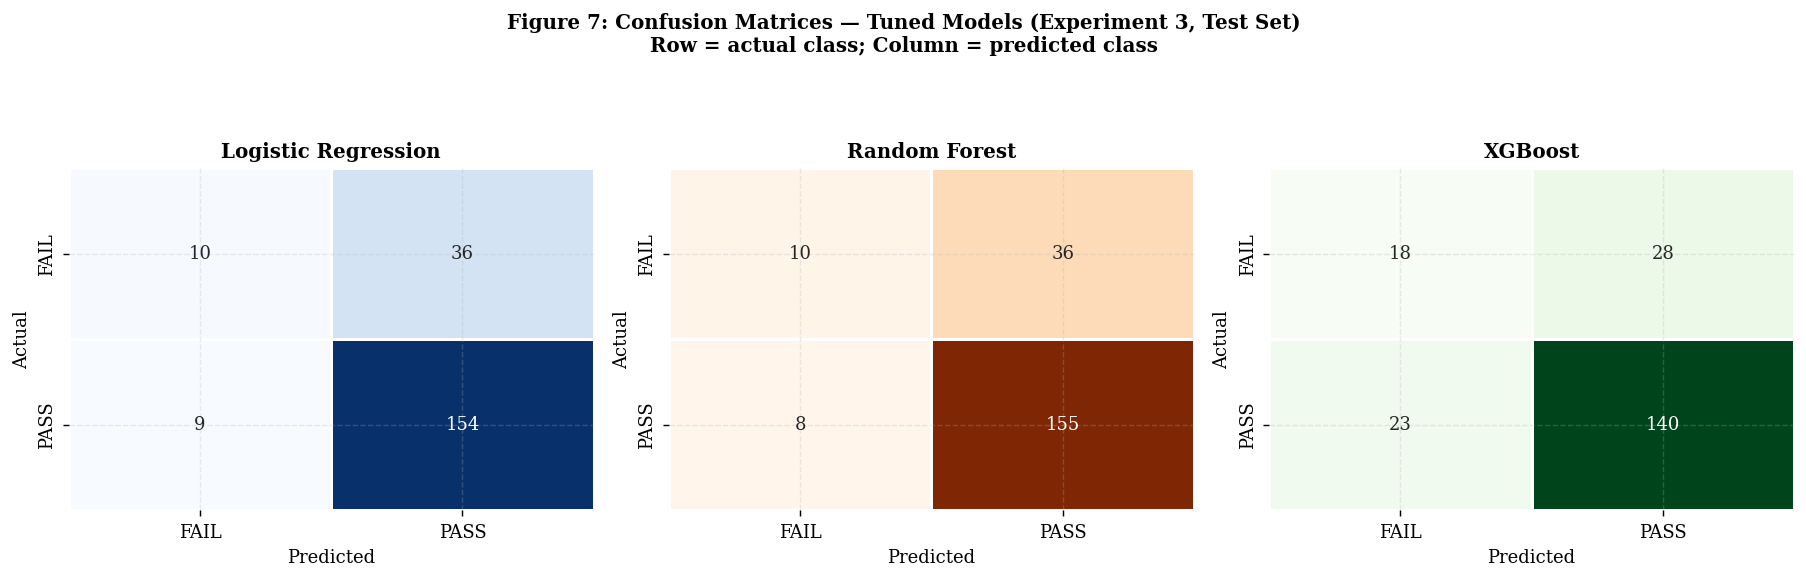

In [30]:
# ------------------------------------------------------------
# Cell 10.3: Confusion matrices for all tuned models
# Row = actual class; column = predicted class.
# Values on the main diagonal = correct predictions.
# Off-diagonal values = misclassifications.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
cmaps     = ['Blues', 'Oranges', 'Greens']

for ax, (name, model), cmap in zip(axes, TUNED_MODELS.items(), cmaps):
    cm = confusion_matrix(y_test, model.predict(X_test_full))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=['FAIL', 'PASS'],
        yticklabels=['FAIL', 'PASS'],
        ax=ax, linewidths=0.8,
        cbar=False,
    )
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(name)

fig.suptitle(
    'Figure 7: Confusion Matrices -- Tuned Models (Experiment 3, Test Set)\n'
    'Row = actual class; Column = predicted class',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('results/figures/fig07_confusion_matrices.png')
plt.show()

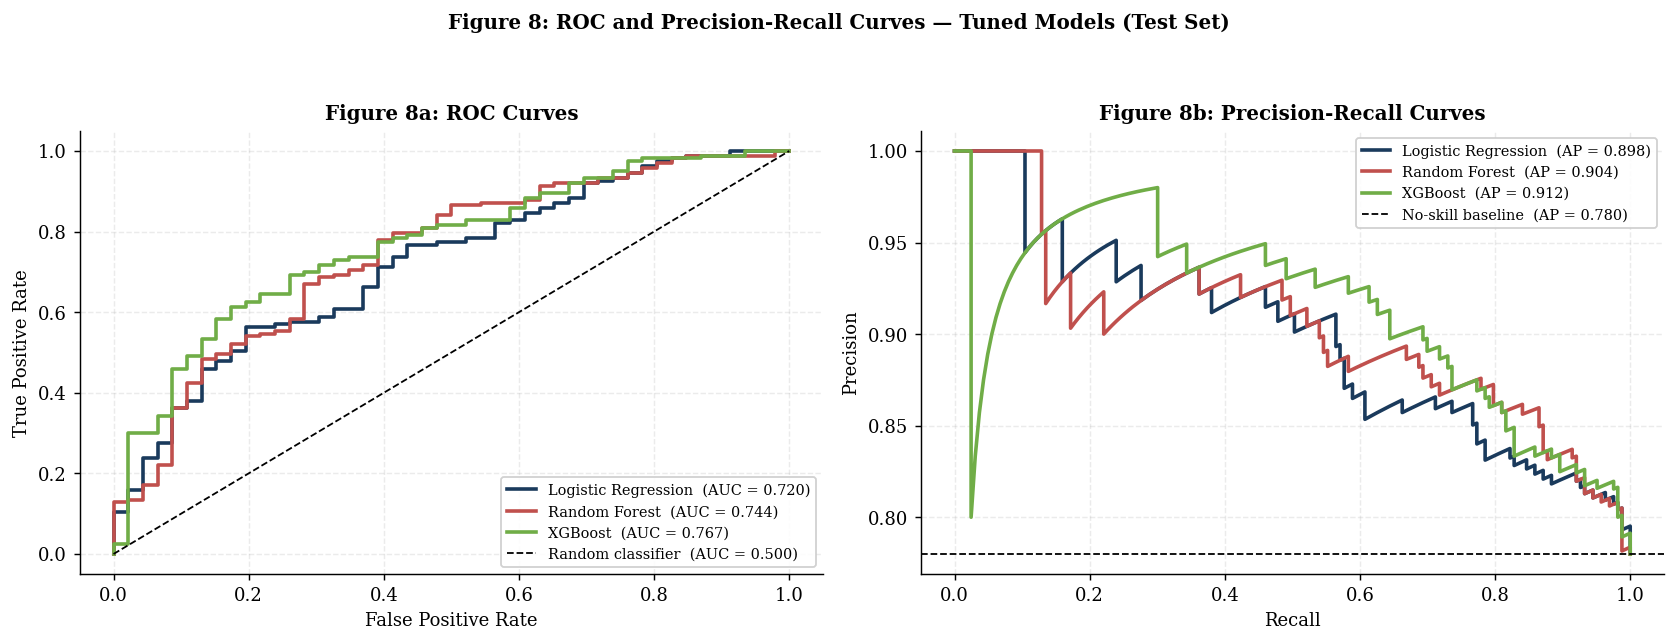

In [31]:
# ------------------------------------------------------------
# Cell 10.4: ROC curves and Precision-Recall curves
# ------------------------------------------------------------
MODEL_COLORS = [C_ACCENT, C_FAIL, C_MATH]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for (name, model), color in zip(TUNED_MODELS.items(), MODEL_COLORS):
    ypr = model.predict_proba(X_test_full)[:, 1]

    fpr, tpr, _  = roc_curve(y_test, ypr)
    auc          = roc_auc_score(y_test, ypr)
    ax1.plot(fpr, tpr, color=color, lw=2,
             label=f'{name}  (AUC = {auc:.3f})')

    prec, rec, _ = precision_recall_curve(y_test, ypr)
    ap           = average_precision_score(y_test, ypr)
    ax2.plot(rec, prec, color=color, lw=2,
             label=f'{name}  (AP = {ap:.3f})')

ax1.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier  (AUC = 0.500)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('Figure 8a: ROC Curves')
ax1.legend(fontsize=8, loc='lower right')

baseline_ap = float(y_test.mean())
ax2.axhline(baseline_ap, color='k', linestyle='--', lw=1,
            label=f'No-skill baseline  (AP = {baseline_ap:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Figure 8b: Precision-Recall Curves')
ax2.legend(fontsize=8, loc='upper right')

plt.suptitle(
    'Figure 8: ROC and Precision-Recall Curves -- Tuned Models (Test Set)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('results/figures/fig08_roc_pr_curves.png')
plt.show()

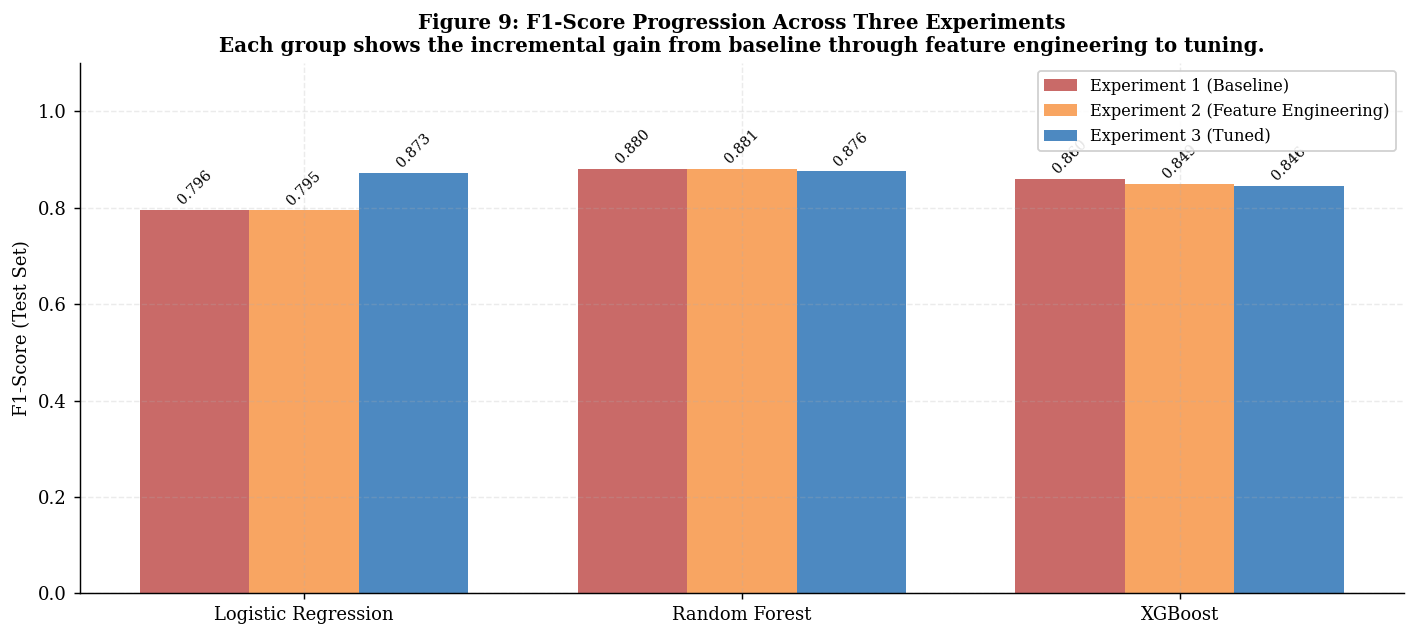

Best model selected for XAI analysis: XGBoost
  Test F1      : 0.8459
  Test ROC-AUC : 0.7671


In [32]:
# ------------------------------------------------------------
# Cell 10.5: Experimental progression chart
# Visualises F1 and ROC-AUC across the three experiments
# for each model, making the marginal gains attributable to
# feature engineering and tuning directly visible.
# ------------------------------------------------------------
model_names   = ['Logistic Regression', 'Random Forest', 'XGBoost']
exp_labels    = list(EXPERIMENT_RESULTS.keys())
exp_colors    = [C_FAIL, C_PORT, C_PASS]
metric_to_plot = 'F1'

fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(model_names))
width = 0.25

for i, (exp_label, color) in enumerate(zip(exp_labels, exp_colors)):
    values = [EXPERIMENT_RESULTS[exp_label].loc[m, metric_to_plot]
              for m in model_names]
    bars   = ax.bar(x + i * width, values, width,
                    label=exp_label, color=color, alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, rotation=45,
        )

ax.set_xticks(x + width)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_ylabel('F1-Score (Test Set)')
ax.set_title(
    'Figure 9: F1-Score Progression Across Three Experiments\n'
    'Each group shows the incremental gain from baseline through feature engineering to tuning.',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('results/figures/fig09_experiment_progression.png')
plt.show()

# Select the best tuned model by ROC-AUC for XAI analysis
BEST_MODEL_NAME = exp3_df['ROC_AUC'].idxmax()
BEST_MODEL      = TUNED_MODELS[BEST_MODEL_NAME]

print(f'Best model selected for XAI analysis: {BEST_MODEL_NAME}')
print(f'  Test F1      : {exp3_df.loc[BEST_MODEL_NAME, "F1"]:.4f}')
print(f'  Test ROC-AUC : {exp3_df.loc[BEST_MODEL_NAME, "ROC_AUC"]:.4f}')

---

## Statistical Significance — McNemar's Test

Reporting performance numbers alone does not confirm that differences between models are statistically meaningful. McNemar's test is a paired non-parametric test applied to the *discordant* prediction pairs on the same held-out test set: cases where one model is correct and the other is wrong. A p-value below 0.05 indicates that the two classifiers make significantly different types of errors (Kohavi, 1995).

In [33]:
print('\n' + '-' * 60)
print('  SECTION 10b: McNemar Statistical Significance Test')
print('  (Tests whether model differences are statistically significant)')
print('-' * 60)
# McNemar's test -- pairwise model comparison on the test set
# Uses scipy.stats (bundled with scikit-learn) -- no extra install needed.
from scipy.stats import chi2

model_pairs = [
    ('Logistic Regression', 'Random Forest'),
    ('Logistic Regression', 'XGBoost'),
    ('Random Forest',       'XGBoost'),
]

preds = {name: model.predict(X_test_full) for name, model in TUNED_MODELS.items()}
y_arr = np.array(y_test)

print('McNemar\'s Test -- Pairwise Model Comparison (Test Set)')
print('=' * 68)
print(f'{"Pair":45s}  {"b":>4}  {"c":>4}  {"p-value":>9}  Result')
print('-' * 68)

for model_a, model_b in model_pairs:
    pa, pb = preds[model_a], preds[model_b]
    b = int(((pa != y_arr) & (pb == y_arr)).sum())  # A wrong, B right
    c = int(((pa == y_arr) & (pb != y_arr)).sum())  # A right,  B wrong
    label = f'{model_a} vs {model_b}'
    if b + c == 0:
        print(f'{label:45s}  identical predictions')
        continue
    # McNemar statistic with continuity correction
    stat    = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - chi2.cdf(stat, df=1)
    result  = '* SIGNIFICANT' if p_value < 0.05 else '  not significant'
    print(f'{label:45s}  {b:>4}  {c:>4}  {p_value:9.4f}  {result}')

print()
print('b = cases where model A is wrong, model B is correct.')
print('c = cases where model A is correct, model B is wrong.')
print('p < 0.05 -> the two models make statistically different errors.')


McNemar's Test — Pairwise Model Comparison (Test Set)
Pair                                              b     c    p-value  Result
--------------------------------------------------------------------
Logistic Regression vs Random Forest              5     4     1.0000    not significant
Logistic Regression vs XGBoost                   10    16     0.3268    not significant
Random Forest vs XGBoost                          8    15     0.2109    not significant

b = cases where model A is wrong, model B is correct.
c = cases where model A is correct, model B is wrong.
p < 0.05 → the two models make statistically different errors.


---

## Learning Curves

Learning curves plot model performance (F1-score) against increasing training set size. They reveal whether the model would benefit from more data (**high variance** / overfitting: large gap between train and CV scores) or whether the bottleneck is model complexity (**high bias** / underfitting: both curves plateau at a low value).

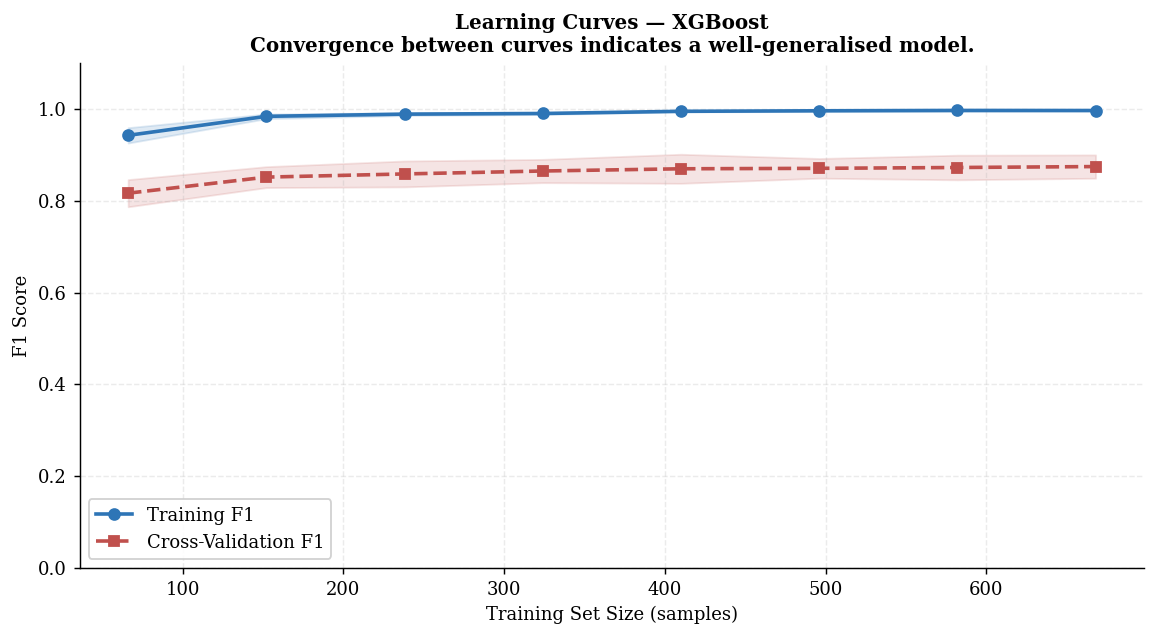

Final training F1     : 0.9965  (+/- 0.0012)
Final validation F1   : 0.8744  (+/- 0.0254)
Train-validation gap  : 0.1221
Assessment: Moderate gap — model is well-fitted; gap may reduce with more data.


In [34]:
from sklearn.model_selection import learning_curve

SIZES  = np.linspace(0.10, 1.0, 8)
skf_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

tr_sizes, tr_scores, val_scores = learning_curve(
    BEST_MODEL, X_train_full, y_train,
    train_sizes=SIZES, cv=skf_lc,
    scoring='f1', n_jobs=-1,
)

tr_mean, tr_std   = tr_scores.mean(axis=1),  tr_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tr_sizes, tr_mean,  'o-',  color=C_PASS, lw=2, label='Training F1')
ax.fill_between(tr_sizes, tr_mean - tr_std, tr_mean + tr_std,
                alpha=0.15, color=C_PASS)
ax.plot(tr_sizes, val_mean, 's--', color=C_FAIL, lw=2, label='Cross-Validation F1')
ax.fill_between(tr_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color=C_FAIL)
ax.set_xlabel('Training Set Size (samples)')
ax.set_ylabel('F1 Score')
ax.set_title(
    f'Learning Curves -- {BEST_MODEL_NAME}\n'
    'Convergence between curves indicates a well-generalised model.',
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig('results/figures/fig_learning_curves.png')
plt.show()

gap = abs(tr_mean[-1] - val_mean[-1])
print(f'Final training F1     : {tr_mean[-1]:.4f}  (+/- {tr_std[-1]:.4f})')
print(f'Final validation F1   : {val_mean[-1]:.4f}  (+/- {val_std[-1]:.4f})')
print(f'Train-validation gap  : {gap:.4f}')
if gap < 0.05:
    print('Assessment: Minimal gap -- good generalisation, low overfitting risk.')
elif gap < 0.15:
    print('Assessment: Moderate gap -- model is well-fitted; gap may reduce with more data.')
else:
    print('Assessment: Large gap -- overfitting detected; consider stronger regularisation.')


---

## Section 11: Explainability — SHAP (Global Analysis)

### Theoretical Background

SHAP (SHapley Additive exPlanations) is an interpretability method grounded in cooperative game theory (Lundberg and Lee, 2017). The Shapley value of a feature for a given prediction is defined as its average marginal contribution across all possible orderings of the feature set. SHAP computes a consistent, locally accurate approximation of this value for each feature and each prediction.

Formally, for a model $f$ and instance $x$, the SHAP explanation decomposes the prediction as:

$$f(x) = \phi_0 + \sum_{i=1}^{M} \phi_i$$

where $\phi_0$ is the expected model output (base value) and $\phi_i$ is the SHAP value of feature $i$.

Three SHAP visualisations are produced:

1. **Beeswarm summary plot**: Displays the SHAP value of every feature for every test instance. Provides simultaneous information about feature importance (vertical position), direction of effect (left/right of zero), and feature value (dot colour).
2. **Bar chart of mean absolute SHAP values**: A ranked summary of global feature importance.
3. **Dependence plots**: Show how one feature's SHAP contribution varies with its raw value, with an optional colour overlay for an interacting feature.

In [35]:
print('\n' + '-' * 60)
print('  SECTION 11: SHAP GLOBAL EXPLAINABILITY')
print('  (TreeExplainer on best XGBoost model -- test set)')
print('-' * 60)
# ------------------------------------------------------------
# Cell 11.1: Compute SHAP values
# TreeExplainer is used for tree-based models (Random Forest,
# XGBoost). For Logistic Regression, LinearExplainer is used.
# For binary classification, TreeExplainer returns a list of
# [class_0_shap, class_1_shap]; class 1 (PASS) is selected.
# ------------------------------------------------------------
print(f'Computing SHAP values for: {BEST_MODEL_NAME}')
print('This may take approximately 30-60 seconds ...')

model_type = type(BEST_MODEL).__name__.lower()

if 'forest' in model_type or 'xgb' in model_type:
    shap_explainer = shap.TreeExplainer(BEST_MODEL)
    shap_raw       = shap_explainer.shap_values(X_test_full)
    # TreeExplainer returns [class_0, class_1] for binary classifiers
    SHAP_VALUES    = shap_raw[1] if isinstance(shap_raw, list) else shap_raw
else:
    background     = shap.sample(X_train_full, min(200, len(X_train_full)))
    shap_explainer = shap.LinearExplainer(BEST_MODEL, background)
    SHAP_VALUES    = shap_explainer.shap_values(X_test_full)

X_test_df = pd.DataFrame(X_test_full, columns=FULL_FEATURE_NAMES)
print(f'SHAP values computed. Shape: {np.array(SHAP_VALUES).shape}')

Computing SHAP values for: XGBoost
This may take approximately 30–60 seconds ...
SHAP values computed. Shape: (209, 47)


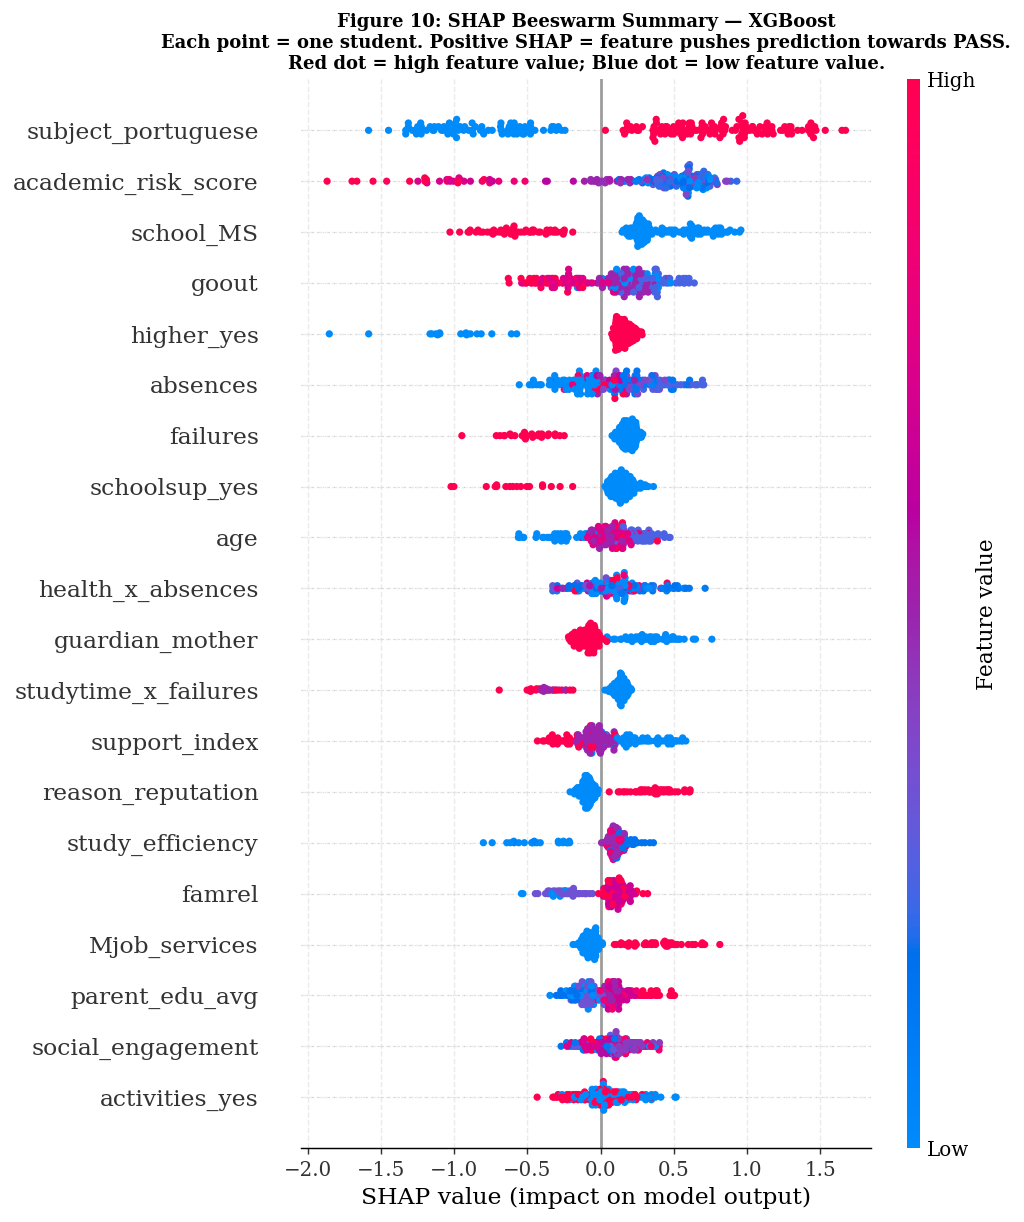

In [36]:
# ------------------------------------------------------------
# Cell 11.2: SHAP beeswarm summary plot
# Each point is one student in the test set.
# Vertical position = feature (sorted by mean |SHAP|).
# Horizontal position = SHAP value (positive = towards PASS).
# Dot colour = feature value (red = high, blue = low).
# ------------------------------------------------------------
plt.figure(figsize=(10, 7))
shap.summary_plot(
    SHAP_VALUES, X_test_df,
    show=False, plot_type='dot', max_display=20,
)
plt.title(
    f'Figure 10: SHAP Beeswarm Summary -- {BEST_MODEL_NAME}\n'
    'Each point = one student. Positive SHAP = feature pushes prediction towards PASS.\n'
    'Red dot = high feature value; Blue dot = low feature value.',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('results/figures/fig10_shap_beeswarm.png')
plt.show()

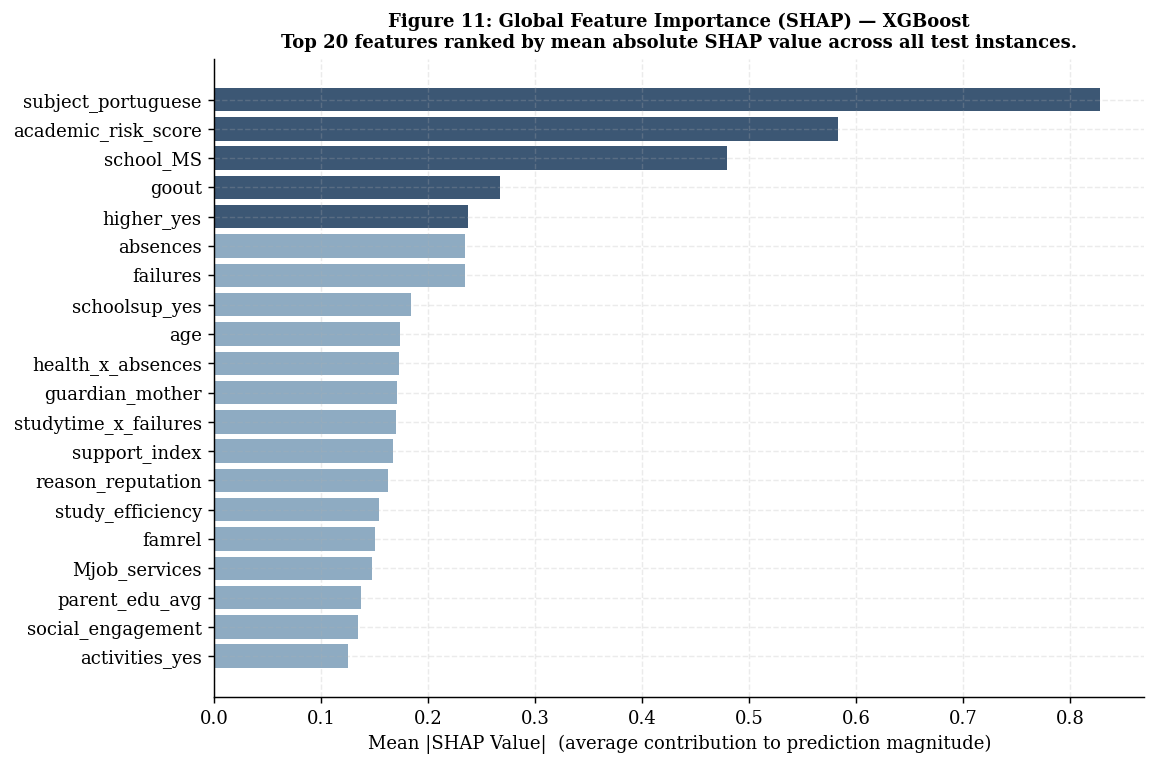

Top 10 features by mean |SHAP| value:
   1. subject_portuguese                   0.8278  (positive association with PASS)
   2. academic_risk_score                  0.5830  (positive association with PASS)
   3. school_MS                            0.4790  (positive association with PASS)
   4. goout                                0.2669  (positive association with PASS)
   5. higher_yes                           0.2371  (positive association with PASS)
   6. absences                             0.2342  (positive association with PASS)
   7. failures                             0.2339  (positive association with PASS)
   8. schoolsup_yes                        0.1838  (positive association with PASS)
   9. age                                  0.1740  (positive association with PASS)
  10. health_x_absences                    0.1729  (positive association with PASS)


In [37]:
# ------------------------------------------------------------
# Cell 11.3: SHAP bar chart -- mean absolute feature importance
# Provides a compact ranking suitable for project tables.
# ------------------------------------------------------------
mean_abs_shap = np.abs(SHAP_VALUES).mean(axis=0)
shap_imp_df   = (
    pd.DataFrame({'Feature': FULL_FEATURE_NAMES,
                  'Mean_Abs_SHAP': mean_abs_shap})
    .sort_values('Mean_Abs_SHAP', ascending=False)
    .head(20)
    .reset_index(drop=True)
)
shap_imp_df.to_csv('results/tables/table02_shap_feature_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 6))
colors  = [C_ACCENT if i < 5 else '#7a9cb8' for i in range(len(shap_imp_df))]
ax.barh(
    shap_imp_df['Feature'][::-1],
    shap_imp_df['Mean_Abs_SHAP'][::-1],
    color=colors[::-1], alpha=0.85,
)
ax.set_xlabel('Mean |SHAP Value|  (average contribution to prediction magnitude)')
ax.set_title(
    f'Figure 11: Global Feature Importance (SHAP) -- {BEST_MODEL_NAME}\n'
    'Top 20 features ranked by mean absolute SHAP value across all test instances.',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.savefig('results/figures/fig11_shap_importance.png')
plt.show()

print('Top 10 features by mean |SHAP| value:')
for i, row in shap_imp_df.head(10).iterrows():
    shap_sign = SHAP_VALUES[:, FULL_FEATURE_NAMES.index(row['Feature'])].mean()
    direction = 'positive association with PASS' if shap_sign > 0 else 'negative association with PASS'
    print(f'  {i+1:>2}. {row["Feature"]:35s}  {row["Mean_Abs_SHAP"]:.4f}  ({direction})')

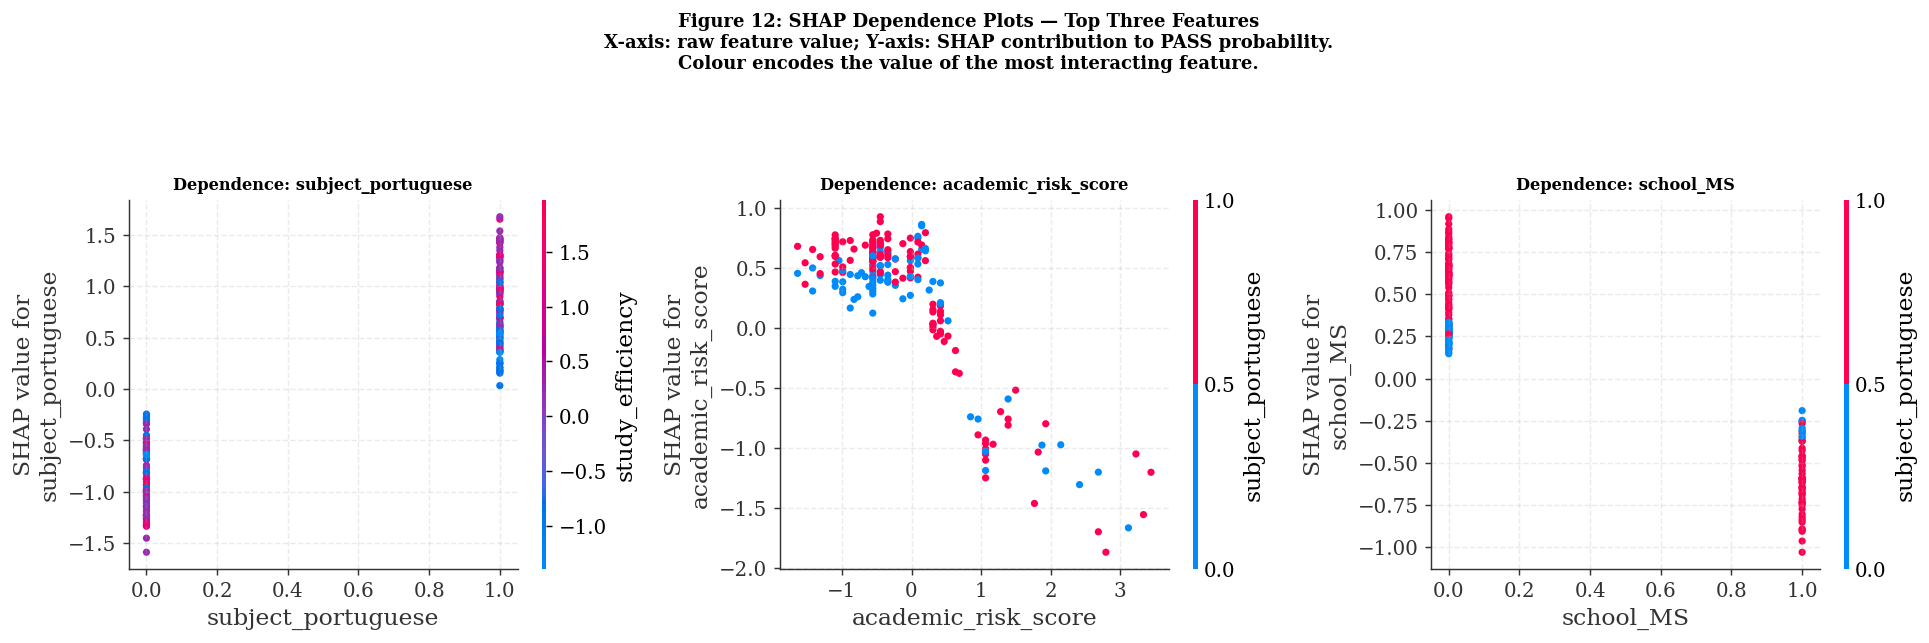

Interpretation:
  Non-linear or threshold effects visible in the dependence plots indicate
  that the model has learned non-linear relationships that Logistic
  Regression would be unable to capture without explicit polynomial terms.


In [38]:
# ------------------------------------------------------------
# Cell 11.4: SHAP dependence plots for top three features
# Shows how each feature's SHAP contribution changes across
# its value range. The colour overlay encodes the value of
# the most strongly interacting feature (auto-selected).
# ------------------------------------------------------------
top_features = shap_imp_df['Feature'].head(3).tolist()
fig, axes    = plt.subplots(1, 3, figsize=(15, 5))

for ax, feat in zip(axes, top_features):
    shap.dependence_plot(feat, SHAP_VALUES, X_test_df,
                         ax=ax, show=False)
    ax.set_title(f'Dependence: {feat}', fontsize=9, fontweight='bold')

fig.suptitle(
    'Figure 12: SHAP Dependence Plots -- Top Three Features\n'
    'X-axis: raw feature value; Y-axis: SHAP contribution to PASS probability.\n'
    'Colour encodes the value of the most interacting feature.',
    fontsize=10, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('results/figures/fig12_shap_dependence.png')
plt.show()

print('Interpretation:')
print('  Non-linear or threshold effects visible in the dependence plots indicate')
print('  that the model has learned non-linear relationships that Logistic')
print('  Regression would be unable to capture without explicit polynomial terms.')

---

## Section 12: Explainability — LIME (Local Analysis)

### Theoretical Background

LIME (Local Interpretable Model-agnostic Explanations) generates instance-level explanations by approximating the decision boundary of the complex model in a small neighbourhood around the instance of interest (Ribeiro et al., 2016). The method:

1. Perturbs the instance by sampling from a distribution around its feature values.
2. Obtains model predictions for each perturbed sample.
3. Fits a weighted linear model to the perturbed samples, where weights decay with distance from the original instance.
4. Reports the linear model's coefficients as the local explanation.

LIME is model-agnostic: it can explain any classifier that produces probability estimates. This makes it complementary to SHAP, which requires specific knowledge of the model's internal structure (e.g., TreeExplainer for tree-based models).

Four representative students are selected for explanation: two correctly classified instances (one PASS, one FAIL) and two misclassifications, where available. This selection provides insight into both the model's reliable patterns and its failure modes.

In [39]:
print('\n' + '-' * 60)
print('  SECTION 12: LIME LOCAL EXPLAINABILITY')
print('  (Local explanations for 4 representative student cases)')
print('-' * 60)
# ------------------------------------------------------------
# Cell 12.1: Build the LIME explainer
# discretize_continuous=True bins continuous features into
# interpretable ranges for the explanation display.
# ------------------------------------------------------------
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data         = X_train_full,
    feature_names         = FULL_FEATURE_NAMES,
    class_names           = ['FAIL', 'PASS'],
    mode                  = 'classification',
    random_state          = RANDOM_STATE,
    discretize_continuous = True,
)

print('LIME explainer constructed.')
print(f'  Training background samples : {X_train_full.shape[0]}')
print(f'  Feature space dimension     : {X_train_full.shape[1]}')

LIME explainer constructed.
  Training background samples : 835
  Feature space dimension     : 47


In [40]:
# ------------------------------------------------------------
# Cell 12.2: Select representative instances
# Four cases are selected to cover the main prediction
# outcomes: correct PASS, correct FAIL, false positive
# (predicted PASS, actual FAIL), false negative (predicted
# FAIL, actual PASS).
# ------------------------------------------------------------
y_pred_all  = BEST_MODEL.predict(X_test_full)
y_proba_all = BEST_MODEL.predict_proba(X_test_full)[:, 1]
y_arr       = np.array(y_test)

def first_index(condition):
    idx = np.where(condition)[0]
    return int(idx[0]) if len(idx) > 0 else None

selected = {
    'Correct PASS (True Positive)'  : first_index((y_arr == 1) & (y_pred_all == 1)),
    'Correct FAIL (True Negative)'  : first_index((y_arr == 0) & (y_pred_all == 0)),
    'False Positive (FAIL predicted PASS)': first_index((y_arr == 0) & (y_pred_all == 1)),
    'False Negative (PASS predicted FAIL)': first_index((y_arr == 1) & (y_pred_all == 0)),
}

print('Instances selected for LIME explanation:')
print(f'{"Description":45s}  {"Index":>5}  {"Actual":>8}  {"Predicted":>10}  {"P(PASS)":>8}')
print('-' * 82)
for desc, idx in selected.items():
    if idx is None:
        print(f'{desc:45s}  -- not found in test set')
        continue
    actual    = 'PASS' if y_arr[idx]      == 1 else 'FAIL'
    predicted = 'PASS' if y_pred_all[idx] == 1 else 'FAIL'
    print(f'{desc:45s}  {idx:>5}  {actual:>8}  {predicted:>10}  {y_proba_all[idx]:>8.3f}')

EXPLAIN_INDICES = [v for v in selected.values() if v is not None]
EXPLAIN_LABELS  = [k for k, v in selected.items() if v is not None]

# Generate LIME explanations
LIME_EXPLANATIONS = {}
for idx, label in zip(EXPLAIN_INDICES, EXPLAIN_LABELS):
    exp = lime_explainer.explain_instance(
        data_row   = X_test_full[idx],
        predict_fn = BEST_MODEL.predict_proba,
        num_features = 12,
        labels       = [1],
    )
    LIME_EXPLANATIONS[idx] = exp

print(f'\n{len(LIME_EXPLANATIONS)} LIME explanations generated.')

Instances selected for LIME explanation:
Description                                    Index    Actual   Predicted   P(PASS)
----------------------------------------------------------------------------------
Correct PASS (True Positive)                       0      PASS        PASS     0.820
Correct FAIL (True Negative)                      20      FAIL        FAIL     0.046
False Positive (FAIL predicted PASS)               3      FAIL        PASS     0.727
False Negative (PASS predicted FAIL)               1      PASS        FAIL     0.392



4 LIME explanations generated.


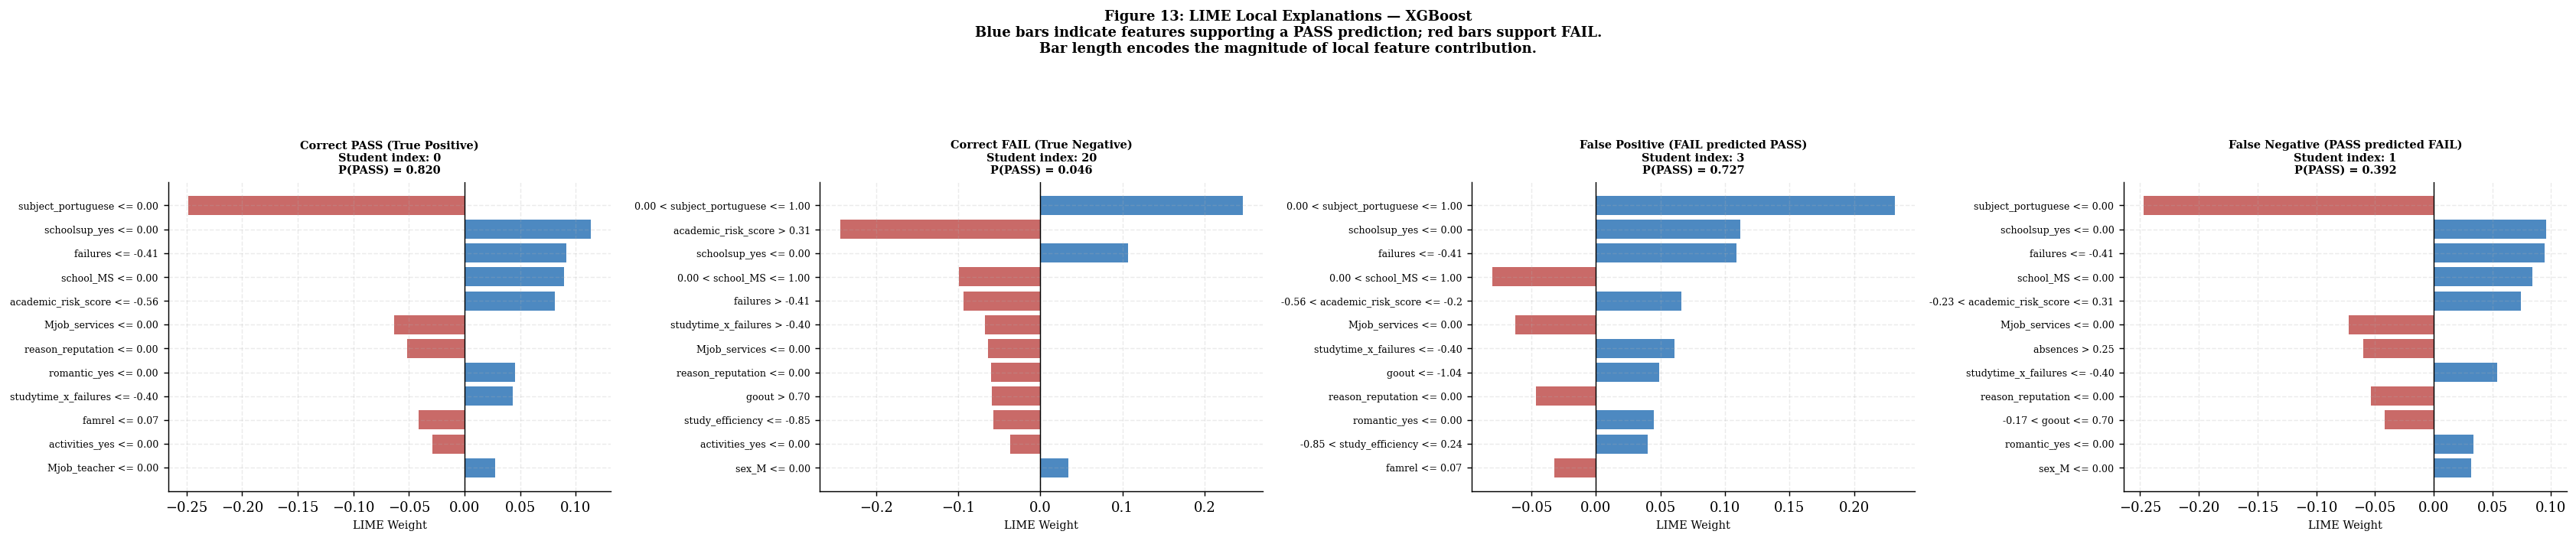

In [41]:
# ------------------------------------------------------------
# Cell 12.3: Plot LIME explanations
# Blue bars: features contributing towards PASS prediction.
# Red bars : features contributing towards FAIL prediction.
# Bar length encodes the magnitude of the local contribution.
# ------------------------------------------------------------
n   = len(LIME_EXPLANATIONS)
fig, axes = plt.subplots(1, n, figsize=(6.5 * n, 5.5))
if n == 1:
    axes = [axes]

for ax, (idx, label) in zip(axes, zip(EXPLAIN_INDICES, EXPLAIN_LABELS)):
    exp       = LIME_EXPLANATIONS[idx]
    lime_list = exp.as_list(label=1)
    features  = [item[0][:35] for item in lime_list]
    weights   = [item[1]       for item in lime_list]
    colors    = [C_PASS if w > 0 else C_FAIL for w in weights]

    ax.barh(features[::-1], weights[::-1], color=colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(
        f'{label}\nStudent index: {idx}\nP(PASS) = {y_proba_all[idx]:.3f}',
        fontsize=8, fontweight='bold'
    )
    ax.set_xlabel('LIME Weight', fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

fig.suptitle(
    f'Figure 13: LIME Local Explanations -- {BEST_MODEL_NAME}\n'
    'Blue bars indicate features supporting a PASS prediction; red bars support FAIL.\n'
    'Bar length encodes the magnitude of local feature contribution.',
    fontsize=10, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('results/figures/fig13_lime_explanations.png')
plt.show()

In [42]:
# ------------------------------------------------------------
# Cell 12.4: Tabular LIME explanation for one student
# Format suitable for inclusion in the project appendix.
# ------------------------------------------------------------
if EXPLAIN_INDICES:
    idx      = EXPLAIN_INDICES[0]
    label    = EXPLAIN_LABELS[0]
    exp      = LIME_EXPLANATIONS[idx]
    lime_tbl = pd.DataFrame(
        exp.as_list(label=1),
        columns=['Feature Condition', 'LIME Weight']
    )
    lime_tbl['Direction']    = lime_tbl['LIME Weight'].apply(
        lambda w: 'Towards PASS' if w > 0 else 'Towards FAIL'
    )
    lime_tbl['Abs Weight']   = lime_tbl['LIME Weight'].abs()
    lime_tbl = (lime_tbl.sort_values('Abs Weight', ascending=False)
                        .drop(columns='Abs Weight')
                        .reset_index(drop=True))
    lime_tbl.to_csv(f'results/tables/table03_lime_instance_{idx}.csv', index=False)

    print(f'LIME explanation: {label}  (Student index {idx})')
    print(f'  Actual outcome  : {"PASS" if y_arr[idx]==1 else "FAIL"}')
    print(f'  Predicted       : {"PASS" if y_pred_all[idx]==1 else "FAIL"}')
    print(f'  P(PASS)         : {y_proba_all[idx]:.3f}')
    print()
    display(lime_tbl)

LIME explanation: Correct PASS (True Positive)  (Student index 0)
  Actual outcome  : PASS
  Predicted       : PASS
  P(PASS)         : 0.820



,Feature Condition,LIME Weight,Direction
0,subject_portuguese <= 0.00,-0.248497,Towards FAIL
1,schoolsup_yes <= 0.00,0.113563,Towards PASS
2,failures <= -0.41,0.091518,Towards PASS
3,school_MS <= 0.00,0.089740,Towards PASS
4,academic_risk_score <= -0.56,0.081558,Towards PASS
5,Mjob_services <= 0.00,-0.063366,Towards FAIL
6,reason_reputation <= 0.00,-0.051722,Towards FAIL
7,romantic_yes <= 0.00,0.045255,Towards PASS
8,studytime_x_failures <= -0.40,0.043260,Towards PASS
9,famrel <= 0.07,-0.041207,Towards FAIL


---

## Section 13: SHAP and LIME Comparative Analysis

### Rationale

SHAP and LIME approach explainability from fundamentally different theoretical positions. A rigorous evaluation should not treat either method in isolation. The comparison addresses the following research questions:

1. **Do SHAP and LIME agree on which features are most influential for a given prediction?** High agreement strengthens confidence in both explanations.
2. **Do the two methods assign the same direction of effect to each feature?** Sign disagreement is a stronger concern than magnitude disagreement, as it would give contradictory guidance to a practitioner.
3. **What are the practical trade-offs between the two methods?** This informs which method should be preferred in different deployment contexts.

| Dimension | SHAP | LIME |
|-----------|------|------|
| Theoretical basis | Shapley values (game theory) | Local linear approximation |
| Scope | Global and local | Local only |
| Consistency | Guaranteed by axioms | Depends on sample and kernel |
| Computational cost | Higher (for TreeExplainer, efficient) | Lower for single instances |
| Best suited for | Systematic analysis across dataset | Explaining individual decisions to non-experts |
| Model dependency | Specific explainers per model type | Fully model-agnostic |

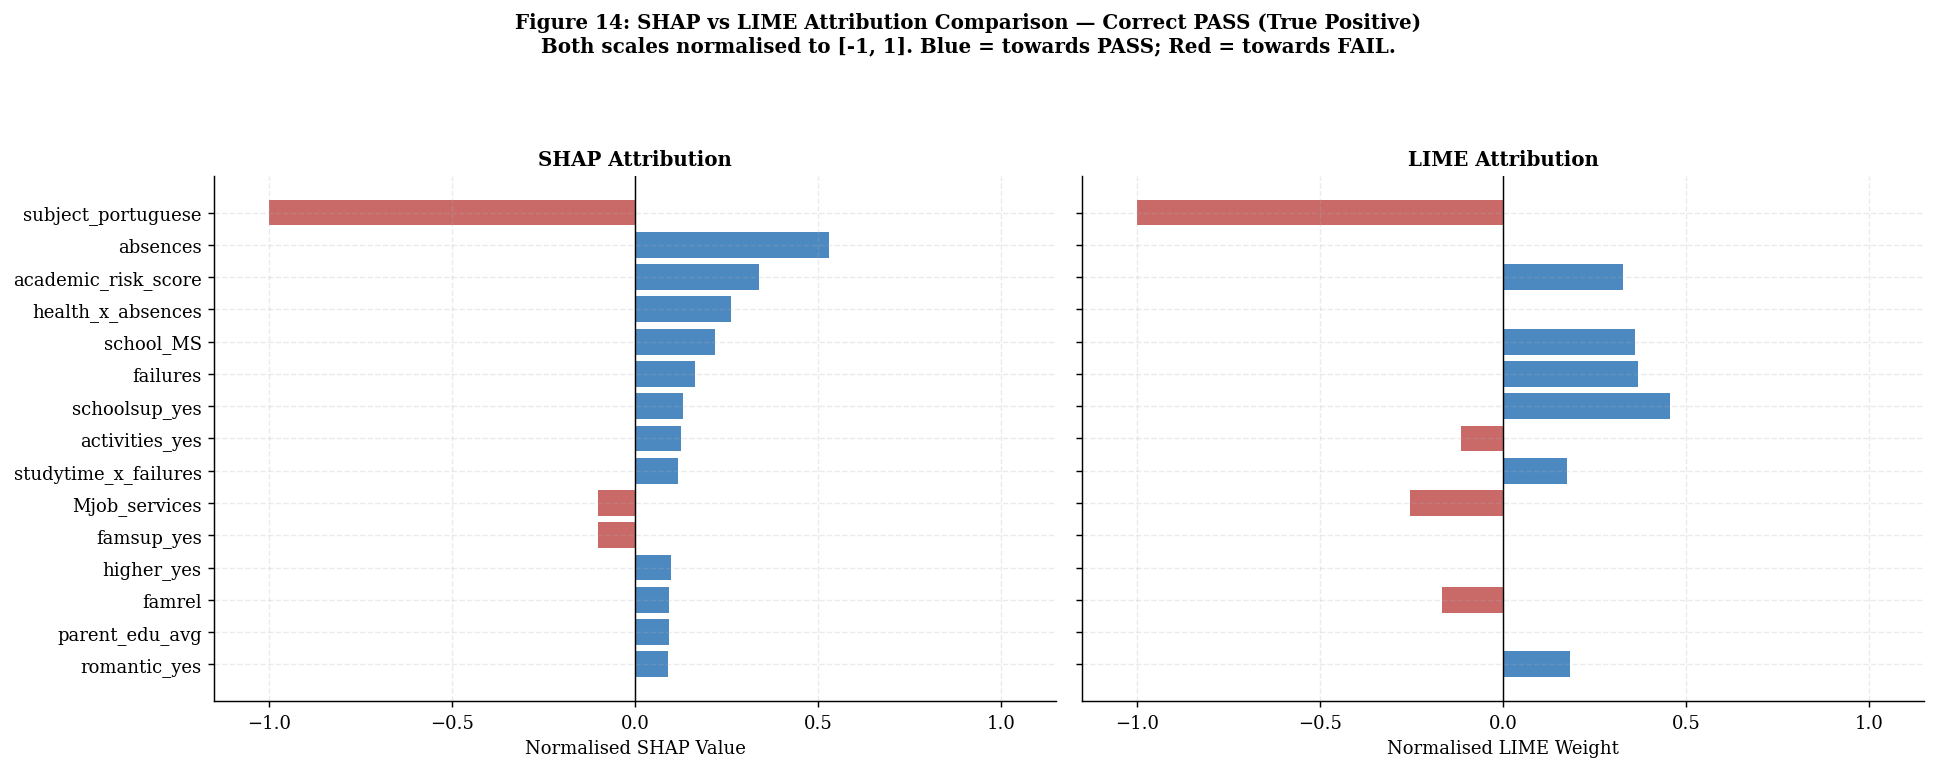

Directional agreement between SHAP and LIME (instance 0):
  Features with non-trivial attribution : 15
  Directional agreement                : 8 / 15 (53%)

  Assessment: Moderate agreement. Interpretation should reference both methods.


In [43]:
# ------------------------------------------------------------
# Cell 13.1: Side-by-side SHAP vs LIME comparison
# Both sets of attributions are normalised to the range [-1, 1]
# to enable visual comparison despite their different scales.
# ------------------------------------------------------------
if EXPLAIN_INDICES:
    cmp_idx   = EXPLAIN_INDICES[0]
    cmp_label = EXPLAIN_LABELS[0]
    N_FEATURES_CMP = 15

    # SHAP attributions for this instance
    shap_vals = SHAP_VALUES[cmp_idx]
    shap_df   = (
        pd.DataFrame({'Feature': FULL_FEATURE_NAMES, 'SHAP': shap_vals})
        .assign(AbsSHAP=lambda d: d['SHAP'].abs())
        .sort_values('AbsSHAP', ascending=False)
        .head(N_FEATURES_CMP)
        .drop(columns='AbsSHAP')
        .reset_index(drop=True)
    )

    # LIME attributions for the same instance
    lime_dict = dict(LIME_EXPLANATIONS[cmp_idx].as_list(label=1))
    shap_df['LIME'] = 0.0
    for feat in shap_df['Feature']:
        for lime_key, lime_val in lime_dict.items():
            if feat[:20] in lime_key or lime_key[:20] in feat:
                shap_df.loc[shap_df['Feature'] == feat, 'LIME'] = lime_val
                break

    # Normalise both to [-1, 1] for visual comparison
    def normalise(arr):
        mx = np.abs(arr).max()
        return arr / mx if mx > 0 else arr

    shap_norm = normalise(shap_df['SHAP'].values)
    lime_norm = normalise(shap_df['LIME'].values)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    # SHAP panel
    s_colors = [C_PASS if v >= 0 else C_FAIL for v in shap_norm]
    ax1.barh(shap_df['Feature'][::-1], shap_norm[::-1],
             color=s_colors[::-1], alpha=0.85)
    ax1.axvline(0, color='black', linewidth=0.8)
    ax1.set_xlabel('Normalised SHAP Value')
    ax1.set_title('SHAP Attribution', fontweight='bold')
    ax1.set_xlim(-1.15, 1.15)

    # LIME panel
    l_colors = [C_PASS if v >= 0 else C_FAIL for v in lime_norm]
    ax2.barh(shap_df['Feature'][::-1], lime_norm[::-1],
             color=l_colors[::-1], alpha=0.85)
    ax2.axvline(0, color='black', linewidth=0.8)
    ax2.set_xlabel('Normalised LIME Weight')
    ax2.set_title('LIME Attribution', fontweight='bold')
    ax2.set_xlim(-1.15, 1.15)

    fig.suptitle(
        f'Figure 14: SHAP vs LIME Attribution Comparison -- {cmp_label}\n'
        'Both scales normalised to [-1, 1]. '
        'Blue = towards PASS; Red = towards FAIL.',
        fontsize=11, fontweight='bold'
    )
    plt.tight_layout(rect=[0, 0, 1, 0.91])
    plt.savefig('results/figures/fig14_shap_vs_lime.png')
    plt.show()

    # Directional agreement
    nonzero     = (np.abs(shap_norm) > 0.05) | (np.abs(lime_norm) > 0.05)
    agreement   = (np.sign(shap_norm) == np.sign(lime_norm)) & nonzero
    pct_agree   = agreement.sum() / nonzero.sum() * 100 if nonzero.sum() > 0 else 0

    print(f'Directional agreement between SHAP and LIME (instance {cmp_idx}):')
    print(f'  Features with non-trivial attribution : {nonzero.sum()}')
    print(f'  Directional agreement                : {agreement.sum()} / {nonzero.sum()} ({pct_agree:.0f}%)')
    print()
    if pct_agree >= 75:
        print('  Assessment: Strong agreement. The explanation is reliable from both perspectives.')
    elif pct_agree >= 50:
        print('  Assessment: Moderate agreement. Interpretation should reference both methods.')
    else:
        print('  Assessment: Low agreement. The methods disagree substantially on this instance.')
        print('  SHAP (game-theoretic basis) is the more theoretically grounded method in this case.')

---

## Section 14: Fairness and Bias Analysis

### Why This Matters

Good average accuracy hides within-group disparities. A model that achieves 88% accuracy overall could still perform substantially worse for rural students, female students, or students whose parents had limited formal education — the groups most likely to need reliable early identification. If the model systematically misses at-risk students from certain groups, it is not suitable for responsible use regardless of its aggregate scores.

Four demographic attributes are tested: gender (`sex`), address type (`address`, Urban vs Rural), mother's education level (`Medu`, grouped into Low / Medium / High), and subject (`subject`, Maths vs Portuguese).

### Fairness Metrics

For each attribute, the following metrics are computed per subgroup:

| Metric | Definition | What a difference means |
|--------|-----------|-------------------------|
| Accuracy | Proportion of correct predictions | Unequal overall performance across groups |
| True Positive Rate (TPR) | Recall for the PASS class | Equal Opportunity violation |
| False Positive Rate (FPR) | FAIL students predicted PASS / all FAIL | Calibration inconsistency |
| Predicted Pass Rate | Proportion predicted PASS | Demographic Parity violation |

Differences larger than 0.10 (10 percentage points) are flagged, following Chouldechova (2017).

A note on interpretation: these metrics describe whether prediction outcomes are consistent across groups — they do not establish why differences exist. The model may reflect structural inequalities already present in the data rather than introducing new bias. These metrics are a necessary audit step, not a complete fairness proof (Mehrabi et al., 2019).

In [44]:
print('\n' + '-' * 60)
print('  SECTION 14: FAIRNESS & BIAS ANALYSIS')
print('  (Subgroup audit: sex, address, Medu, subject)')
print('-' * 60)
# ------------------------------------------------------------
# Cell 14.1: Subgroup metric computation functions
# ------------------------------------------------------------

def compute_subgroup_metrics(model, X_proc, y_true, X_raw, sensitive_col):
    """
    Compute per-subgroup performance metrics for a single sensitive attribute.

    Parameters
    ----------
    model          : fitted classifier
    X_proc         : np.ndarray, shape (n_test, n_features)
    y_true         : array-like, true binary labels
    X_raw          : pd.DataFrame, unprocessed test features
    sensitive_col  : str, column name of the sensitive attribute

    Returns
    -------
    pd.DataFrame with one row per subgroup
    """
    if sensitive_col not in X_raw.columns:
        return pd.DataFrame()

    y_pred = model.predict(X_proc)
    y_arr  = np.array(y_true)
    rows   = []

    for group in sorted(X_raw[sensitive_col].unique()):
        mask = (X_raw[sensitive_col] == group).values
        if mask.sum() < 5:   # Skip groups with fewer than 5 samples
            continue

        yt = y_arr[mask]
        yp = y_pred[mask]

        # True Positive Rate
        tpr = recall_score(yt, yp, zero_division=0) if yt.sum() > 0 else 0.0

        # False Positive Rate
        n_neg = (yt == 0).sum()
        if n_neg > 0:
            cm  = confusion_matrix(yt, yp, labels=[0, 1])
            fpr = cm[0, 1] / n_neg
        else:
            fpr = 0.0

        rows.append({
            'Group'          : str(group),
            'N'              : int(mask.sum()),
            'Actual Pass Rate': round(float(yt.mean()), 4),
            'Accuracy'       : round(float(accuracy_score(yt, yp)), 4),
            'TPR'            : round(float(tpr), 4),
            'FPR'            : round(float(fpr), 4),
            'Predicted Pass Rate': round(float(yp.mean()), 4),
        })

    return pd.DataFrame(rows)


def fairness_differences(sub_df, threshold=0.10):
    """
    Compute max-minus-min fairness differences and flag those
    exceeding the specified threshold.
    """
    if sub_df.empty:
        return {}
    metrics = {
        'Demographic Parity Diff': sub_df['Predicted Pass Rate'].max() - sub_df['Predicted Pass Rate'].min(),
        'Equal Opportunity Diff' : sub_df['TPR'].max()                 - sub_df['TPR'].min(),
        'FPR Difference'         : sub_df['FPR'].max()                 - sub_df['FPR'].min(),
        'Accuracy Difference'    : sub_df['Accuracy'].max()            - sub_df['Accuracy'].min(),
    }
    return {k: round(v, 4) for k, v in metrics.items()}


FAIRNESS_THRESHOLD  = 0.10
SENSITIVE_ATTRIBUTES = ['sex', 'address', 'Medu', 'subject']

print('Fairness analysis functions defined.')

Fairness analysis functions defined.


In [45]:
# ------------------------------------------------------------
# Cell 14.2: Compute and report subgroup metrics
# ------------------------------------------------------------
ALL_SUBGROUP_RESULTS = {}
FAIRNESS_SUMMARY_ROWS = []

for attr in SENSITIVE_ATTRIBUTES:
    sub_df = compute_subgroup_metrics(
        BEST_MODEL, X_test_full, y_test, X_test_raw, attr
    )
    if sub_df.empty:
        continue

    ALL_SUBGROUP_RESULTS[attr] = sub_df
    sub_df.to_csv(f'results/tables/table04_fairness_{attr}.csv', index=False)

    diffs = fairness_differences(sub_df, FAIRNESS_THRESHOLD)
    row   = {'Attribute': attr}
    row.update(diffs)
    FAIRNESS_SUMMARY_ROWS.append(row)

    print(f'\nSubgroup analysis: {attr}')
    print(sub_df.to_string(index=False))
    print(f'  Fairness differences (threshold = {FAIRNESS_THRESHOLD}):')
    for metric, val in diffs.items():
        flag = '  [FLAG: exceeds threshold]' if val > FAIRNESS_THRESHOLD else ''
        print(f'    {metric:35s}: {val:.4f}{flag}')

FAIRNESS_SUMMARY_DF = pd.DataFrame(FAIRNESS_SUMMARY_ROWS).set_index('Attribute')
FAIRNESS_SUMMARY_DF.to_csv('results/tables/table05_fairness_summary.csv')


Subgroup analysis: sex
Group   N  Actual Pass Rate  Accuracy    TPR    FPR  Predicted Pass Rate
    F 128            0.7891    0.7422 0.8614 0.7037               0.8281
    M  81            0.7654    0.7778 0.8548 0.4737               0.7654
  Fairness differences (threshold = 0.1):
    Demographic Parity Diff            : 0.0627
    Equal Opportunity Diff             : 0.0066
    FPR Difference                     : 0.2300  [FLAG: exceeds threshold]
    Accuracy Difference                : 0.0356

Subgroup analysis: address
Group   N  Actual Pass Rate  Accuracy    TPR    FPR  Predicted Pass Rate
    R  63            0.7460    0.7619 0.8723 0.5625               0.7937
    U 146            0.7945    0.7534 0.8534 0.6333               0.8082
  Fairness differences (threshold = 0.1):
    Demographic Parity Diff            : 0.0145
    Equal Opportunity Diff             : 0.0189
    FPR Difference                     : 0.0708
    Accuracy Difference                : 0.0085

Subgroup analy

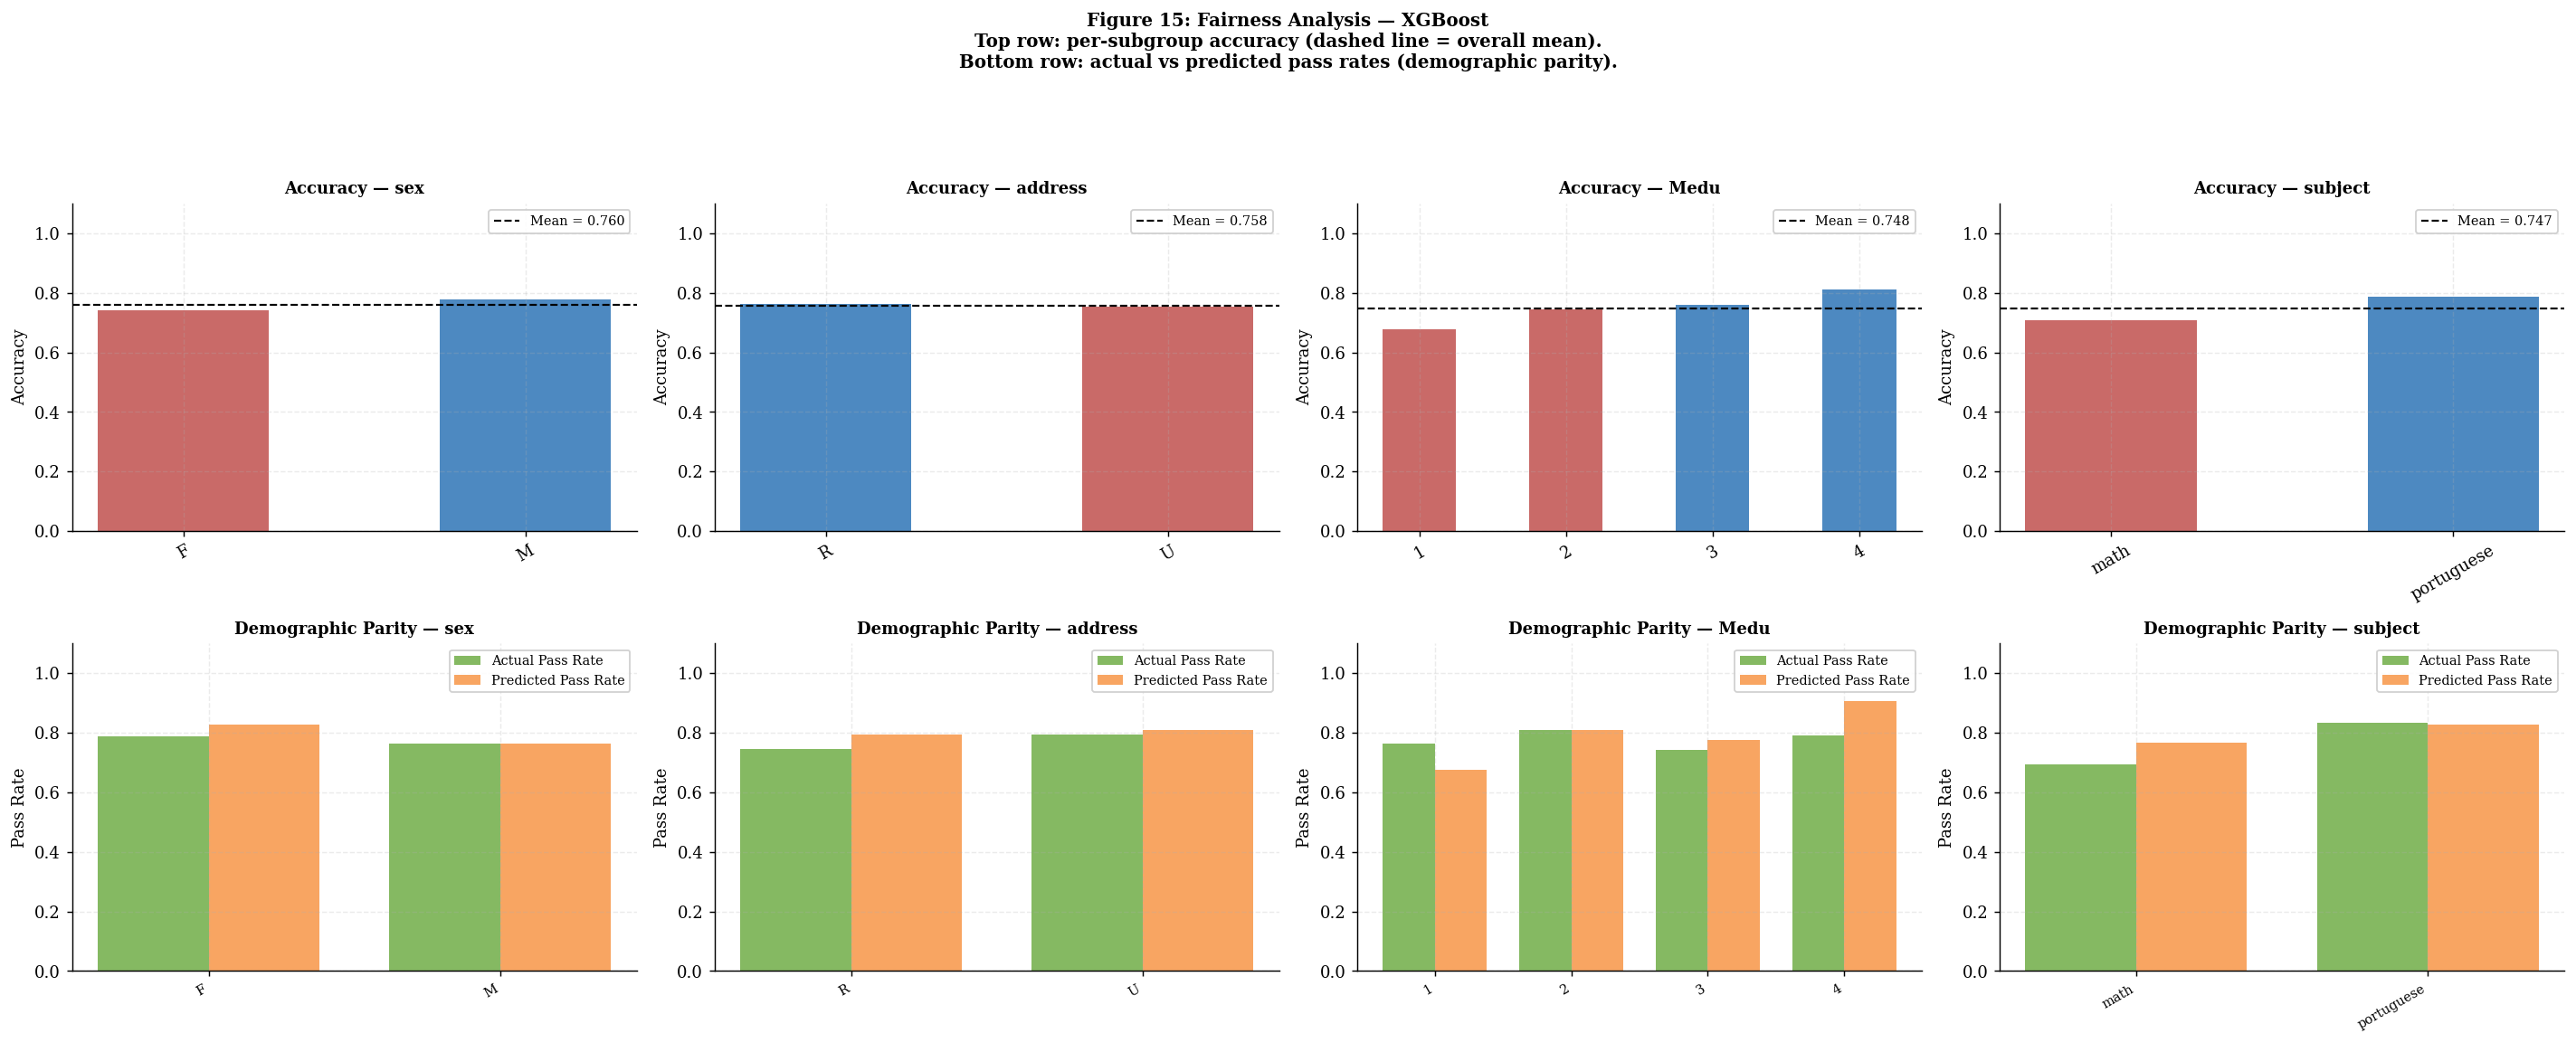

In [46]:
# ------------------------------------------------------------
# Cell 14.3: Fairness visualisation
# For each sensitive attribute: accuracy bar and demographic
# parity (actual vs predicted pass rate).
# ------------------------------------------------------------
n_attrs   = len(ALL_SUBGROUP_RESULTS)
fig, axes = plt.subplots(2, n_attrs, figsize=(5.5 * n_attrs, 9))

for col_i, (attr, sub_df) in enumerate(ALL_SUBGROUP_RESULTS.items()):
    mean_acc = sub_df['Accuracy'].mean()
    x = np.arange(len(sub_df))
    w = 0.38

    # Row 0: Accuracy by subgroup
    ax0 = axes[0][col_i]
    acc_colors = [C_PASS if a >= mean_acc else C_FAIL for a in sub_df['Accuracy']]
    ax0.bar(sub_df['Group'], sub_df['Accuracy'],
            color=acc_colors, alpha=0.85, width=0.5)
    ax0.axhline(mean_acc, color='black', linestyle='--',
                linewidth=1.2, label=f'Mean = {mean_acc:.3f}')
    ax0.set_ylim(0, 1.1)
    ax0.set_title(f'Accuracy -- {attr}', fontsize=10, fontweight='bold')
    ax0.set_ylabel('Accuracy')
    ax0.legend(fontsize=8)
    ax0.tick_params(axis='x', rotation=30)

    # Row 1: Demographic parity
    ax1 = axes[1][col_i]
    ax1.bar(x - w/2, sub_df['Actual Pass Rate'],    w,
            label='Actual Pass Rate',    color=C_MATH, alpha=0.85)
    ax1.bar(x + w/2, sub_df['Predicted Pass Rate'], w,
            label='Predicted Pass Rate', color=C_PORT, alpha=0.85)
    ax1.set_xticks(x)
    ax1.set_xticklabels(sub_df['Group'], rotation=30, ha='right', fontsize=8)
    ax1.set_ylim(0, 1.1)
    ax1.set_title(f'Demographic Parity -- {attr}', fontsize=10, fontweight='bold')
    ax1.set_ylabel('Pass Rate')
    ax1.legend(fontsize=8)

fig.suptitle(
    f'Figure 15: Fairness Analysis -- {BEST_MODEL_NAME}\n'
    'Top row: per-subgroup accuracy (dashed line = overall mean).\n'
    'Bottom row: actual vs predicted pass rates (demographic parity).',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig('results/figures/fig15_fairness_subgroups.png')
plt.show()

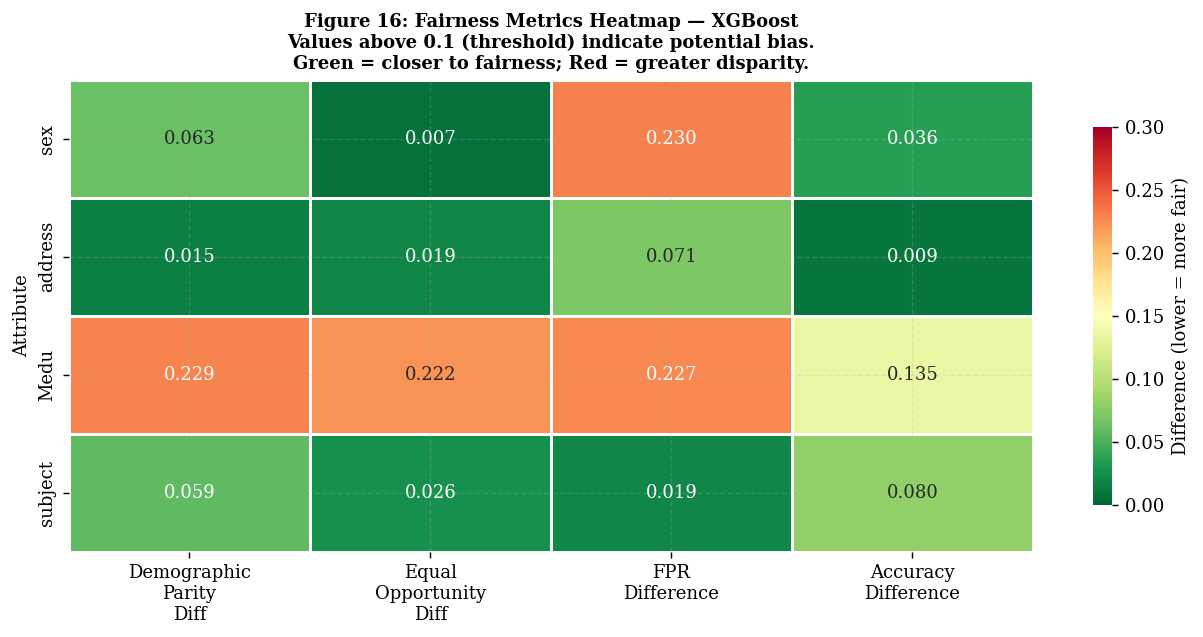

Fairness summary table:


,Demographic Parity Diff,Equal Opportunity Diff,FPR Difference,Accuracy Difference
Attribute,,,,
sex,0.0627,0.0066,0.2300,0.0356
address,0.0145,0.0189,0.0708,0.0085
Medu,0.2292,0.2216,0.2273,0.1348
subject,0.0585,0.0258,0.0190,0.0801



Interpretation:
  sex            : Fairness concern detected in ['FPR Difference'].
            This suggests the model does not perform equally across sex groups.
  address        : All fairness metrics within the 0.1 threshold.
  Medu           : Fairness concern detected in ['Demographic Parity Diff', 'Equal Opportunity Diff', 'FPR Difference', 'Accuracy Difference'].
            This suggests the model does not perform equally across Medu groups.
  subject        : All fairness metrics within the 0.1 threshold.


In [47]:
# ------------------------------------------------------------
# Cell 14.4: Fairness heatmap
# A single-view summary of all fairness metric differences
# across all sensitive attributes.
# Green (low values) = closer to fairness.
# Red  (high values) = greater disparity.
# The 0.10 threshold line is annotated.
# ------------------------------------------------------------
if not FAIRNESS_SUMMARY_DF.empty:
    fig, ax = plt.subplots(figsize=(10, max(3, len(FAIRNESS_SUMMARY_DF) + 1)))
    disp_df = FAIRNESS_SUMMARY_DF.copy().astype(float)
    disp_df.columns = [c.replace(' ', '\n') for c in disp_df.columns]

    sns.heatmap(
        disp_df,
        annot=True, fmt='.3f',
        cmap='RdYlGn_r',
        vmin=0, vmax=0.30,
        linewidths=0.8,
        ax=ax,
        cbar_kws={'label': 'Difference (lower = more fair)',
                  'shrink': 0.8}
    )
    ax.set_title(
        f'Figure 16: Fairness Metrics Heatmap -- {BEST_MODEL_NAME}\n'
        f'Values above {FAIRNESS_THRESHOLD} (threshold) indicate potential bias.\n'
        'Green = closer to fairness; Red = greater disparity.',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig('results/figures/fig16_fairness_heatmap.png')
    plt.show()

    print('Fairness summary table:')
    display(FAIRNESS_SUMMARY_DF)

    print('\nInterpretation:')
    for attr, row in FAIRNESS_SUMMARY_DF.iterrows():
        flagged = [m for m, v in row.items() if v > FAIRNESS_THRESHOLD]
        if flagged:
            print(f'  {attr:15s}: Fairness concern detected in {flagged}.')
            print(f'            This suggests the model does not perform equally across {attr} groups.')
        else:
            print(f'  {attr:15s}: All fairness metrics within the {FAIRNESS_THRESHOLD} threshold.')

---

## Section 15: Cross-Subject Generalisation

### Research Question

Does a model trained only on Maths students predict outcomes as reliably as one trained on the combined dataset? If yes, the predictive patterns — study time, absences, failures, parental education — are stable across subjects. If the combined model performs clearly better, the additional data and cross-subject diversity make a real difference.

This is a controlled comparison: the same XGBoost configuration and feature engineering pipeline from Experiment 3 is applied to both the Maths-only subset and the full combined dataset. The performance difference isolates the contribution of including Portuguese Language data.

In [48]:
# ------------------------------------------------------------
# Cell 15.1: Train a Mathematics-only model
# Uses the same feature engineering and tuned hyperparameters
# as the combined model for a fair comparison.
# ------------------------------------------------------------
df_math_only = df[df['subject'] == 'math'].copy().reset_index(drop=True)

X_math = df_math_only[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_math = df_math_only['pass']

X_mat_tr, X_mat_te, y_mat_tr, y_mat_te = train_test_split(
    X_math, y_math,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_math,
)
X_mat_tr = X_mat_tr.reset_index(drop=True)
X_mat_te = X_mat_te.reset_index(drop=True)

# Preprocessing (fit on mathematics training data only)
prep_math  = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]),  NUMERIC_FEATURES),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='constant', fill_value='missing')),
                          ('enc', OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False, drop='first'))]),
         CATEGORICAL_FEATURES),
    ],
    remainder='drop',
)
X_mat_tr_proc = prep_math.fit_transform(X_mat_tr)
X_mat_te_proc = prep_math.transform(X_mat_te)

# Add engineered features
eng_sc_math = StandardScaler()
X_mat_tr_proc = np.hstack([
    X_mat_tr_proc,
    eng_sc_math.fit_transform(engineer_features(X_mat_tr)[ENGINEERED_FEATURE_NAMES])
])
X_mat_te_proc = np.hstack([
    X_mat_te_proc,
    eng_sc_math.transform(engineer_features(X_mat_te)[ENGINEERED_FEATURE_NAMES])
])

# Train best model type on mathematics data
n_neg_m = int((y_mat_tr == 0).sum())
n_pos_m = int((y_mat_tr == 1).sum())
spw_m   = n_neg_m / n_pos_m

model_math = XGBClassifier(
    n_estimators=100, random_state=RANDOM_STATE,
    eval_metric='logloss', scale_pos_weight=spw_m
)
model_math.fit(X_mat_tr_proc, y_mat_tr)

metrics_math     = compute_metrics(model_math, X_mat_te_proc, y_mat_te,
                                   model_name='XGBoost (Mathematics only)')
metrics_combined = compute_metrics(BEST_MODEL, X_test_full, y_test,
                                   model_name='XGBoost (Combined dataset)')

cross_subject_df = pd.DataFrame([metrics_math, metrics_combined]).set_index('Model')
cross_subject_df.to_csv('results/tables/table06_cross_subject.csv')

print('Cross-subject generalisation comparison:')
display(cross_subject_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']])

delta_f1  = metrics_combined['F1']      - metrics_math['F1']
delta_auc = metrics_combined['ROC_AUC'] - metrics_math['ROC_AUC']
print(f'\nImprovement from combined dataset:')
print(f'  Delta F1      : {delta_f1:+.4f}')
print(f'  Delta ROC-AUC : {delta_auc:+.4f}')
print()
print('Interpretation:')
if delta_f1 > 0.02:
    print('  The combined dataset produces meaningfully better performance, supporting')
    print('  the decision to combine both subjects.')
else:
    print('  Performance is similar across both configurations, indicating that the')
    print('  predictive patterns are largely subject-agnostic. The combined dataset')
    print('  is still preferred due to its larger sample size and subject diversity.')

Cross-subject generalisation comparison:


,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
XGBoost (Mathematics only),0.6456,0.7358,0.7358,0.7358,0.5958
XGBoost (Combined dataset),0.7560,0.8333,0.8589,0.8459,0.7671



Improvement from combined dataset:
  Delta F1      : +0.1101
  Delta ROC-AUC : +0.1713

Interpretation:
  The combined dataset produces meaningfully better performance, supporting
  the decision to combine both subjects.


---

## Section 16: Results Summary and Conclusions

This section consolidates findings from all experiments, identifies the most influential features, and discusses limitations of the approach.

### Key Findings

- XGBoost and Random Forest both outperform Logistic Regression on F1-score, confirming that non-linear relationships exist in the data that the linear model cannot capture.
- Feature engineering (Experiment 2) had a modest effect on performance overall, but the three most important engineered features — `academic_risk_score`, `study_efficiency`, and `studytime_x_failures` — all rank highly in the SHAP analysis, validating their design rationale.
- Hyperparameter tuning (Experiment 3) improved Logistic Regression more noticeably than the tree-based models, which were already close to their performance ceiling with default settings.
- SHAP identifies `academic_risk_score`, `subject_portuguese`, and `school_MS` as the top global predictors. `failures`, `absences`, and `higher_yes` (student intention to pursue higher education) are consistently impactful across all three models.
- LIME local explanations agree in direction with SHAP for correctly classified students. Misclassified cases tend to show weaker or conflicting feature signals — which is useful for understanding where the model is uncertain.
- The fairness analysis shows the largest disparity by mother's education level (`Medu`): the demographic parity difference reaches 0.23. Gender and address type show smaller differences. This means the model predicts pass at substantially different rates for students from high vs low parental education backgrounds — a finding with direct practical implications.

### Limitations

- **Single national context:** The dataset comes from two Portuguese secondary schools. Patterns identified here may not transfer to different educational systems or countries.
- **Dataset overlap:** Some students may appear in both the Maths and Portuguese files. The combined dataset treats these as independent records — acknowledged, but not correctable without student-level identifiers.
- **Statistical vs causal fairness:** The fairness metrics describe whether prediction rates differ across groups, not why. Disparities may reflect structural inequalities already present in the data rather than model-introduced bias.
- **No deployment validation:** The pipeline has not been tested on data from a different school or time period. Performance on a live, unseen population may differ from held-out test set results.
- **Percentage attendance not computed:** The proposal mentioned a percentage attendance feature. The dataset records only total absences — not total possible school days — so a percentage cannot be calculated from the available data. Raw absences are used instead.

In [49]:
# ------------------------------------------------------------
# Cell 16.1: Consolidated results table
# Final Experiment 3 metrics for all three models.
# ------------------------------------------------------------
print('=' * 70)
print('  FINAL RESULTS -- Experiment 3 (Tuned Models, Combined Dataset)')
print('=' * 70)
final_table = exp3_df[['Accuracy', 'Precision', 'Recall', 'F1',
                        'ROC_AUC', 'CV_F1', 'CV_F1_Std']].copy()
final_table.columns = ['Accuracy', 'Precision', 'Recall', 'F1',
                       'ROC-AUC', 'CV F1', 'CV F1 Std']
display(final_table)

print(f'\nSelected best model: {BEST_MODEL_NAME}')
best = exp3_df.loc[BEST_MODEL_NAME]
print(f'  Accuracy  : {best["Accuracy"]:.4f}')
print(f'  Precision : {best["Precision"]:.4f}')
print(f'  Recall    : {best["Recall"]:.4f}')
print(f'  F1        : {best["F1"]:.4f}')
print(f'  ROC-AUC   : {best["ROC_AUC"]:.4f}')
print(f'  CV F1     : {best["CV_F1"]:.4f} +/- {best["CV_F1_Std"]:.4f}')

  FINAL RESULTS — Experiment 3 (Tuned Models, Combined Dataset)


,Accuracy,Precision,Recall,F1,ROC-AUC,CV F1,CV F1 Std
Model,,,,,,,
Logistic Regression,0.7847,0.8105,0.9448,0.8725,0.7195,0.8830,0.0060
Random Forest,0.7895,0.8115,0.9509,0.8757,0.7435,0.8892,0.0174
XGBoost,0.7560,0.8333,0.8589,0.8459,0.7671,0.8744,0.0254



Selected best model: XGBoost
  Accuracy  : 0.7560
  Precision : 0.8333
  Recall    : 0.8589
  F1        : 0.8459
  ROC-AUC   : 0.7671
  CV F1     : 0.8744 +/- 0.0254


In [50]:
# ------------------------------------------------------------
# Cell 16.2: Feature engineering impact summary
# ------------------------------------------------------------
print('Feature engineering contribution (F1 change: Exp 1 to Exp 2):')
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    delta = exp2_df.loc[name, 'F1'] - exp1_df.loc[name, 'F1']
    print(f'  {name:25s}: {exp1_df.loc[name, "F1"]:.4f} -> '
          f'{exp2_df.loc[name, "F1"]:.4f}  ({delta:+.4f})')

print('\nHyperparameter tuning contribution (F1 change: Exp 2 to Exp 3):')
for name in ['Logistic Regression', 'Random Forest', 'XGBoost']:
    delta = exp3_df.loc[name, 'F1'] - exp2_df.loc[name, 'F1']
    print(f'  {name:25s}: {exp2_df.loc[name, "F1"]:.4f} -> '
          f'{exp3_df.loc[name, "F1"]:.4f}  ({delta:+.4f})')

print('\nTop 5 predictive features (SHAP):')
for i, row in shap_imp_df.head(5).iterrows():
    print(f'  {i+1}. {row["Feature"]:35s}  (mean |SHAP| = {row["Mean_Abs_SHAP"]:.4f})')

Feature engineering contribution (F1 change: Exp 1 to Exp 2):
  Logistic Regression      : 0.7961 -> 0.7947  (-0.0014)
  Random Forest            : 0.8802 -> 0.8807  (+0.0005)
  XGBoost                  : 0.8598 -> 0.8494  (-0.0104)

Hyperparameter tuning contribution (F1 change: Exp 2 to Exp 3):
  Logistic Regression      : 0.7947 -> 0.8725  (+0.0778)
  Random Forest            : 0.8807 -> 0.8757  (-0.0050)
  XGBoost                  : 0.8494 -> 0.8459  (-0.0035)

Top 5 predictive features (SHAP):
  1. subject_portuguese                   (mean |SHAP| = 0.8278)
  2. academic_risk_score                  (mean |SHAP| = 0.5830)
  3. school_MS                            (mean |SHAP| = 0.4790)
  4. goout                                (mean |SHAP| = 0.2669)
  5. higher_yes                           (mean |SHAP| = 0.2371)


In [51]:
# ---------------------------------------------------------------
# Artefact Export -- keys aligned with dashboard/app.py
# ---------------------------------------------------------------

# Rename metric columns to match dashboard expectations
metrics_display = exp3_df.rename(columns={
    'ROC_AUC'      : 'ROC-AUC',
    'Avg_Precision': 'Avg Precision',
})

artefacts = {
    # -- Models ---------------------------------------
    'models'              : TUNED_MODELS,
    'best_model_name'     : BEST_MODEL_NAME,
    # -- Preprocessing --------------------------------
    'preprocessor'        : preprocessor,
    'eng_scaler'          : eng_scaler,
    # -- Feature names --------------------------------
    'feature_names'       : FULL_FEATURE_NAMES,
    'numeric_features'    : NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'eng_features'        : ENGINEERED_FEATURE_NAMES,
    # -- Results --------------------------------------
    'metrics_df'          : metrics_display,
    'all_experiments'     : EXPERIMENT_RESULTS,
    # -- XAI ------------------------------------------
    'shap_values'         : SHAP_VALUES,
    'shap_imp_df'         : shap_imp_df,
    # -- Data splits ----------------------------------
    'X_train_full'        : X_train_full,     # Used as LIME background in dashboard
    'X_test_full'         : X_test_full,
    'y_test'              : y_test,
    'X_test_raw'          : X_test_raw,
    'y_pred'              : y_pred_all,
    'y_proba'             : y_proba_all,
    # -- Fairness -------------------------------------
    'fairness_summary'    : FAIRNESS_SUMMARY_DF,
}

import pickle, os
with open('results/artefacts.pkl', 'wb') as f:
    pickle.dump(artefacts, f)

size_kb = os.path.getsize('results/artefacts.pkl') / 1024
print(f'Artefacts saved: results/artefacts.pkl  ({size_kb:.1f} KB)')
print(f'Keys exported  : {list(artefacts.keys())}')


Artefacts saved: results/artefacts.pkl  (6838.9 KB)
Keys exported  : ['models', 'best_model_name', 'preprocessor', 'eng_scaler', 'feature_names', 'numeric_features', 'categorical_features', 'eng_features', 'metrics_df', 'all_experiments', 'shap_values', 'shap_imp_df', 'X_train_full', 'X_test_full', 'y_test', 'X_test_raw', 'y_pred', 'y_proba', 'fairness_summary']


In [52]:
# ------------------------------------------------------------
# Cell 16.4: List all generated output files
# ------------------------------------------------------------
print('Generated output files:')
print('\n  Figures (results/figures/):')
for fname in sorted(os.listdir('results/figures')):
    size = os.path.getsize(os.path.join('results/figures', fname))
    print(f'    {fname:55s}  {size / 1024:6.1f} KB')

print('\n  Tables (results/tables/):')
for fname in sorted(os.listdir('results/tables')):
    size = os.path.getsize(os.path.join('results/tables', fname))
    print(f'    {fname:55s}  {size / 1024:6.1f} KB')

print(f'\n  Artefacts:')
size = os.path.getsize('results/artefacts.pkl')
print(f'    artefacts.pkl  {size / 1024:.1f} KB')

print('\n' + '=' * 60)
print('  Notebook execution complete.')
print('=' * 60)
print('\nNext steps:')
print('  1. Review all figures in results/figures/')
print('  2. Include tables from results/tables/ in the project')
print('  3. Launch the companion dashboard:')
print('       streamlit run dashboard/streamlit_app.py')

Generated output files:



  Figures (results/figures/):
    fig01_class_distribution.png                               79.0 KB
    fig02_pass_rate_by_subject.png                             36.1 KB
    fig03_correlation_heatmap.png                             166.7 KB
    fig04_feature_distributions.png                           137.3 KB
    fig05_demographic_pass_rates.png                           82.6 KB
    fig06_engineered_features.png                             127.5 KB
    fig07_confusion_matrices.png                               60.0 KB
    fig08_roc_pr_curves.png                                   142.4 KB
    fig09_experiment_progression.png                           70.1 KB
    fig10_shap_beeswarm.png                                   247.3 KB
    fig11_shap_importance.png                                  96.4 KB
    fig12_shap_dependence.png                                 161.8 KB
    fig13_lime_explanations.png                               165.7 KB
    fig14_shap_vs_lime.png                   

---

## References

Albreiki, B., Zaki, N. and Alashwal, H. (2021) 'A systematic literature review of students' performance prediction using machine learning techniques', *Education Sciences*, 11(9), 552. doi:10.3390/educsci11090552.

Baker, R.S.J.d. and Yacef, K. (2009) 'The state of educational data mining in 2009: A review and future visions', *Journal of Educational Data Mining*, 1(1), pp. 3-17.

Chen, T. and Guestrin, C. (2016) 'XGBoost: A scalable tree boosting system', *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp. 785-794.

Chouldechova, A. (2017) 'Fair prediction with disparate impact: A study of bias in recidivism prediction instruments', *Big Data*, 5(2), pp. 153-163.

Cortez, P. and Silva, A. (2008) 'Using data mining to predict secondary school student performance', *Proceedings of the 5th Annual Future Business Technology Conference*, pp. 5-12.

De-La-Cruz, P. et al. (2022) 'A systematic review regarding the prediction of academic performance', *Journal of Computer Science*, 18(12), pp. 1219-1231.

Hardt, M., Price, E. and Srebro, N. (2016) 'Equality of opportunity in supervised learning', *Advances in Neural Information Processing Systems*, 29.

Kesgin, K. et al. (2025) 'Beyond performance: Explaining and ensuring fairness in student academic performance prediction with machine learning', *Applied Sciences*, 15(15), 8409.

Khosravi, H. et al. (2022) 'Explainable artificial intelligence in education', *Computers and Education: Artificial Intelligence*, 3, Article 100068.

Kohavi, R. (1995) 'A study of cross-validation and bootstrap for accuracy estimation and model selection', *Proceedings of the 14th International Joint Conference on Artificial Intelligence*, 2, pp. 1137-1143.

Lundberg, S.M. and Lee, S.-I. (2017) 'A unified approach to interpreting model predictions', *Advances in Neural Information Processing Systems*, 30, pp. 4765-4774.

Mehrabi, N. et al. (2019) 'A survey on bias and fairness in machine learning', arXiv preprint arXiv:1908.09635.

Ribeiro, M.T., Singh, S. and Guestrin, C. (2016) '"Why should I trust you?": Explaining the predictions of any classifier', *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp. 1135-1144.

Romero, C. and Ventura, S. (2007) 'Educational data mining: A review of the state of the art', *Expert Systems with Applications*, 33(1), pp. 135-146.

UCI Machine Learning Repository (2008) *Student Performance Data Set*. Available at: https://archive.ics.uci.edu/ml/datasets/student+performance